# CUDA FIT BESSEL

### 1. Modello $\cos^4$ — serie di Bessel

Il tasso di scattering $C_4$ tetragonale con anisotropia $\cos^4$:

$$\Gamma(\varphi) = \Gamma_{is} + \Gamma_{an}\cos^4(2\varphi)$$

Il valor medio sull'orbita ciclotrone si scompone come:

$$\cos^4(2\varphi) = \frac{3}{8} + \frac{1}{2}\cos(4\varphi) + \frac{1}{8}\cos(8\varphi)$$

da cui si definisce la frequenza di scattering **effettiva** (parte isotropa più correzione media del termine $\cos^4$):

$$\tilde{\Gamma} = \Gamma_{is} + \frac{3}{8}\,\Gamma_{an}$$

L'integrale di Chambers, dopo espansione in serie di Fourier e uso delle funzioni di Bessel modificate, dà:

$$\sigma_{xx} + i\,\sigma_{xy} = \pi\,\overline{\sum_t (-1)^t\,\Omega(t)\, \frac{\tilde{\Gamma} - i\,\omega_ct^*}{\tilde{\Gamma}^2 + (\omega_ct^*)^2}}$$

dove la barra indica il complesso coniugato (convenzione hole-like), $\omega_c = \frac{K\cdot B}{m^*}$ con $K = 0.116\ \text{meV/T}$, $t^*=4t+1$ e $\Omega(t)$ è una combinazione di prodotti di funzioni di Bessel modificate $I_n(\alpha)$ e $I_n(\alpha/8)$ con **parametro di Bessel**:

$$\alpha = \frac{\Gamma_{an}}{8\,\omega_c}$$

La magnetoresistenza è:

$$\text{MR}(B) = \frac{\sigma_{xx}(B_\text{ref})}{\sigma_{xx}(B)} - 1$$

**Parametri liberi del fit:** $\Gamma_{is}$, $\Gamma_{an}$, $m^*$ (universale), $A$ (riscalamento globale di $\rho$).

> **Nota — divergenza di Bessel per $\alpha \to \infty$:**  
> Quando $B \to 0$ con $\Gamma_{an} > 0$ si ha $\alpha = \Gamma_{an}/(8\omega_c) \to \infty$. Le funzioni $I_n(\alpha) \sim e^\alpha/\sqrt{2\pi\alpha}$ esplodono e la serie diventa numericamente instabile. Per questo si impone un campo minimo:
> $$B_\text{ref} = \frac{\Gamma_{an}\,m^*}{8\,K\,\alpha_\text{ref}}, \qquad \alpha_\text{ref} = 10$$
> Al di sotto di $B_\text{ref}$, $\sigma_{xx}$ e MR non vengono calcolati (taglio dei dati a basso campo).

In [42]:
# Carichiamo entrambi i file
import chambers_lib as cl
import numpy as np
import cupy as cp
import cupyx.scipy.special as cps
from scipy.special import iv as iv_cpu
from scipy.optimize import curve_fit, differential_evolution
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display, Markdown
import ipywidgets as widgets
import chambers_lib as cl
from chambers_lib import (com_omega, eval_T_dep)
import time
import gc

print('\nLibrerie caricate correttamente!\n')

arr = cl.load_ataei_extended([2, 6])

# Definiamo le temperature e dove si trovano le coppie (B, R) nell'array 'arr'
# Per Nd-LSCO:
# 4K -> col 0,1 | 40K -> col 2,3 | 100K -> col 4,5 | 30K -> col 10,11 (perché MOESM6 ha 6 colonne prima)
# Tuttavia, per semplicità, mappiamole manualmente:
T_MAPPING = {
    4.0: (0, 1),
    30.0: (10, 11), # Le ultime due colonne di MOESM6 (che era il secondo file caricato)
    40.0: (2, 3),
    100.0: (4, 5)
}

T_LIST = [4.0, 30.0, 40.0, 100.0]
colors = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    idx_B, idx_R = T_MAPPING[T]
    B = arr[:, idx_B]
    R = arr[:, idx_R]
    
    m = (~np.isnan(B)) & (~np.isnan(R)) & (B > 0)
    DATA[T] = (B[m], R[m])
    
    print(f"T = {T:4.0f} K : N = {m.sum():5d} B in [{B[m].min():.2f}, {B[m].max():.2f}] T")
K_MEV = 0.116


Librerie caricate correttamente!

T =    4 K : N =  3872 B in [13.41, 84.61] T
T =   30 K : N =  9427 B in [0.20, 84.88] T
T =   40 K : N = 10272 B in [0.10, 85.25] T
T =  100 K : N =  9895 B in [0.10, 85.36] T


In [43]:
try:
    # Prende la GPU principale (ID 0)
    device = cp.cuda.Device(0)
    
    # Estrae le proprietà hardware
    props = cp.cuda.runtime.getDeviceProperties(device.id)
    name = props['name'].decode('utf-8') # Decodifica il nome da bytes a stringa
    vram = props['totalGlobalMem'] / (1024**3) # Calcolo in GiB effettivi
    
    print("Device: CUDA (GPU Ready 🚀)")
    print(f"  GPU: {name}")
    print(f"  VRAM: {vram:.1f} GB")
    
except Exception as e:
    print("Device: CPU (CUDA non disponibile, fallback su NumPy)")

Device: CUDA (GPU Ready 🚀)
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU
  VRAM: 8.0 GB


In [44]:
def com_alpha(G_an, B, m_star):
    """Parametro di anisotropia Bessel:  alpha = G_an / (8 * hbar*omega_c)."""
    return G_an / (8.0 * com_omega(B, m_star))

def _sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    """
    Versione CUDA ibrida del modello cos^4.
    Le funzioni di Bessel vengono valutate su CPU, mentre la contrazione
    tensoriale (il vero collo di bottiglia) esplode la potenza di CuPy.
    """
    B = np.atleast_1d(B).astype(float)
    
    # --- 1. PRE-CALCOLO CPU (cupyx non ha iv di ordine arbitrario) ---
    alpha = com_alpha(G_an, B, m_star)
    omega = com_omega(B, m_star)
    
    s_arr  = np.arange(-s_max, s_max + 1)
    N_all  = np.concatenate([2*s_arr, 2*s_arr + 1])
    mu_arr = np.arange(-mu_max, mu_max + 1)
    
    N_abs  = int(np.max(np.abs(N_all)))
    k_al   = np.arange(0, t_max + 2*mu_max + 2*N_abs + 1)
    k_al8  = np.arange(0, mu_max + N_abs + 1)

    alpha_gpu_1d = cp.asarray(alpha)
    I_al  = iv_table_gpu(int(k_al[-1]),  alpha_gpu_1d)
    I_al8 = iv_table_gpu(int(k_al8[-1]), alpha_gpu_1d / 8.0)
    omega_gpu = cp.asarray(omega)
    
    s_arr_gpu  = cp.asarray(s_arr)
    sign_s     = (-1.0) ** s_arr_gpu
    N_all_gpu  = cp.asarray(N_all)
    mu_arr_gpu = cp.asarray(mu_arr)
    sign_mu    = (-1.0) ** mu_arr_gpu
    
    G_tilde = G_is + 3 * G_an / 8.0
    
    iv_mu_al8  = I_al8[cp.abs(mu_arr_gpu), :]
    iv_muN_al8 = I_al8[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :]
    
    ns = len(s_arr)
    temp = cp.zeros(len(B), dtype=complex)
    
    # --- 3. CICLO PESANTE (Motore Tensor CUDA) ---
    for t in range(-t_max, t_max + 1):
        t_an   = 4 * t + 1
        denom  = G_tilde**2 + (omega_gpu * t_an)**2
        sign_t = (-1.0) ** t
        
        iv_tm_al  = I_al[cp.abs(t - 2*mu_arr_gpu), :]
        iv_tmN_al = I_al[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :]
        
        A_mu = sign_mu[:, None] * iv_tm_al * iv_mu_al8
        
        zeta_all = cp.einsum('mb,mnb,mnb->nb', A_mu, iv_tmN_al, iv_muN_al8)
        
        sum_s_c = cp.sum(sign_s[:, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0)
        inner_c = (G_tilde - 1j * omega_gpu * t_an) * sum_s_c
        
        temp += sign_t * inner_c / denom
        
    return cp.asnumpy(cp.conj(cp.pi * temp))

def sigma_xx_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.real(_sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def sigma_xy_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.imag(_sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def _B_ref_bessel(G_an, m_star, alpha_ref=10.0, B_min=0.5):
    return max(G_an * m_star / (8.0 * K_MEV * alpha_ref), B_min)

def MR_Bessel(B, G_is, G_an, m_star):
    B = np.atleast_1d(B).astype(float)
    B_ref = _B_ref_bessel(G_an, m_star)
    
    sig0 = sigma_xx_Bessel(np.array([B_ref]), G_is, G_an, m_star)[0]
    out = np.full_like(B, np.nan)
    mask = B >= B_ref
    
    if mask.any():
        sig_stab = sigma_xx_Bessel(B[mask], G_is, G_an, m_star)
        out[mask] = sig0 / sig_stab - 1.0
        
    return out

def iv_table_gpu(n_max, x):
    """
    I_n(x) per n = 0..n_max, interamente su GPU (algoritmo di Miller).

    Parameters
    ----------
    n_max : int          ordine massimo (incluso)
    x     : cp.ndarray   argomenti reali strettamente positivi (qualsiasi forma)

    Returns
    -------
    cp.ndarray di forma (n_max+1,) + x.shape, dtype float64
        out[n, ...] = I_n(x[...])
    """
    shape = x.shape
    xf = cp.ascontiguousarray(x.ravel().astype(cp.float64))
    N  = xf.size

    x_max = float(cp.max(xf))
    n_start = max(n_max + int(np.sqrt(40.0 * (n_max + 1))) + 20,
                  2 * int(x_max) + n_max + 10)

    inv_x = 1.0 / xf

    I_unnorm     = cp.zeros((n_max + 1, N), dtype=cp.float64)
    log_scale_at = cp.zeros((n_max + 1, N), dtype=cp.float64)

    Inp1      = cp.zeros(N, dtype=cp.float64)
    In        = cp.ones (N, dtype=cp.float64)
    log_scale = cp.zeros(N, dtype=cp.float64)

    THRESH = 1e150

    for n in range(n_start, -1, -1):
        if n <= n_max:
            I_unnorm[n]     = In
            log_scale_at[n] = log_scale

        Inm1 = (2.0 * n) * In * inv_x + Inp1
        Inp1 = In
        In   = Inm1

        # Rescaling per-elemento ogni 8 passi per limitare i sync GPU→CPU
        if (n & 7) == 0:
            mx = cp.maximum(cp.abs(In), cp.abs(Inp1))
            if bool(cp.any(mx > THRESH)):
                scale     = cp.where(mx > THRESH, 1.0 / mx, 1.0)
                In       *= scale
                Inp1     *= scale
                log_scale = log_scale - cp.log(scale)

    log_I0    = cp.log(cps.i0(xf))
    log_un    = cp.log(cp.maximum(cp.abs(I_unnorm), 1e-300))
    log_I     = (log_un + log_scale_at) - (log_un[0:1] + log_scale_at[0:1]) + log_I0[None, :]
    I_final   = cp.exp(log_I)

    return I_final.reshape((n_max + 1,) + shape)
# ====================================================================
# MOTORE CUDA BATCH VETTORIZZATO (loop su t con vettorizzazione su mu e N)
# ====================================================================
def compute_batch_MR_Bessel_GPU_v2(B_gpu, G_is_batch, G_an_batch, m_star,
                                    t_max=30, s_max=2, mu_max=10):
    K_MEV   = 0.116
    N_b     = len(B_gpu)
    N_batch = len(G_is_batch)

    # ── omega ────────────────────────────────────────────────────────
    B_ref   = cp.maximum(G_an_batch * m_star / (8.0 * K_MEV * 10.0), 0.5)
    omega_B = K_MEV * B_gpu / m_star
    omega_r = K_MEV * B_ref / m_star
    omega   = cp.empty((N_batch, N_b + 1), dtype=cp.float64)
    omega[:, :N_b] = omega_B[None, :]
    omega[:, N_b]  = omega_r
    alpha   = G_an_batch[:, None] / (8.0 * omega)

    # ── index arrays ─────────────────────────────────────────────────
    s_arr  = cp.arange(-s_max,  s_max  + 1)
    ns     = len(s_arr)
    N_all  = cp.concatenate([2*s_arr, 2*s_arr + 1])
    mu_arr = cp.arange(-mu_max, mu_max + 1)
    N_abs  = int(cp.max(cp.abs(N_all)))
    t_arr  = cp.arange(-t_max,  t_max  + 1)

    sign_s  = (-1.0) ** s_arr   # (ns,)
    sign_mu = (-1.0) ** mu_arr  # (M,)
    sign_t  = (-1.0) ** t_arr   # (T_size,)
    t_an    = t_arr * 4.0 + 1.0

    # ── Bessel tables: (K+1, N_batch, N_b+1) ────────────────────────
    I_al  = iv_table_gpu(t_max + 2*mu_max + 2*N_abs, alpha)
    I_al8 = iv_table_gpu(mu_max + N_abs,             alpha / 8.0)

    # ── per-mu terms condivisi tra tutti gli step-t ───────────────────
    iv_mu_al8  = I_al8[cp.abs(mu_arr), :, :]                            # (M, batch, ω)
    iv_muN_al8 = I_al8[cp.abs(mu_arr[:, None] - N_all[None, :]), :, :]  # (M, N_size, batch, ω)

    # ── accumula sigma_xx iterando su t — evita tensore (T,M,batch,ω) ─
    G_tilde   = G_is_batch + 3.0 * G_an_batch / 8.0   # (batch,)
    temp_real = cp.zeros((N_batch, N_b + 1), dtype=cp.float64)

    for t_idx in range(2 * t_max + 1):
        t_val   = int(t_arr[t_idx])
        st      = float(sign_t[t_idx])
        omega_t = float(t_an[t_idx]) * omega             # (batch, ω)
        denom   = G_tilde[:, None]**2 + omega_t**2       # (batch, ω)

        # A_mu: (M, batch, ω)
        iv_tm = I_al[cp.abs(t_val - 2 * mu_arr), :, :]
        A_mu  = sign_mu[:, None, None] * iv_tm * iv_mu_al8
        del iv_tm

        # iv_tmN_all: (M, N_size, batch, ω) — advanced indexing
        idx_n      = cp.abs(t_val - 2 * mu_arr[:, None] + 2 * N_all[None, :])  # (M, N_size)
        iv_tmN_all = I_al[idx_n, :, :]

        # zeta_t: (N_size, batch, ω) = Σ_m A_mu[m] * iv_tmN[m,n] * C_n[m,n]
        B_mn   = A_mu[:, None, :, :] * iv_muN_al8                # (M, N_size, batch, ω)
        zeta_t = cp.sum(B_mn * iv_tmN_all, axis=0)               # (N_size, batch, ω)
        del A_mu, B_mn, iv_tmN_all, idx_n

        # real((G - iω)(s_re - i·s_im)) = G·s_re - ω·s_im
        s_re = cp.einsum('n,nbw->bw', sign_s, zeta_t[:ns])       # (batch, ω)
        s_im = cp.einsum('n,nbw->bw', sign_s, zeta_t[ns:])       # (batch, ω)
        del zeta_t

        ic_real    = G_tilde[:, None] * s_re - omega_t * s_im
        temp_real += st * ic_real / denom
        del s_re, s_im, ic_real, omega_t, denom

    del iv_mu_al8, iv_muN_al8

    sigma    = cp.pi * temp_real
    sig_stab = sigma[:, :N_b]
    sig_0    = sigma[:, N_b]
    return (sig_0[:, None] / sig_stab) - 1.0

# ====================================================================
# PRE-CHECK VRAM SUPER-SCANNER
# ====================================================================
def check_vram_superscan(limit_gb=None):
    # Parametri fissi della funzione compute_batch_MR_Bessel_GPU_v2
    t_max_f, s_max_f, mu_max_f = 30, 2, 10
    s_arr_f = np.arange(-s_max_f, s_max_f + 1)
    N_all_f = np.concatenate([2*s_arr_f, 2*s_arr_f + 1])
    N_size  = len(N_all_f)                          # 10
    N_abs   = int(np.max(np.abs(N_all_f)))          # 5
    M       = 2 * mu_max_f + 1                      # 21
    K       = t_max_f + 2*mu_max_f + 2*N_abs        # 60  → K+1=61 righe in I_al
    K8      = mu_max_f + N_abs                       # 15  → K8+1=16 righe in I_al8

    if limit_gb is None:
        limit_gb = vram - 0.5

    max_Nb = max(len(DATA_FINAL[T][0]) for T in T_LIST)
    N_w    = max_Nb + 1   # +1 per B_ref

    # VRAM occupata dalla cache Bessel di cella 16 (se ancora allocata)
    bytes_cache = 0
    if BESSEL_CACHE_DICT:
        for m_cache, td in BESSEL_CACHE_DICT.items():
            for T_cache, (I1, I2, om) in td.items():
                bytes_cache += I1.nbytes + I2.nbytes + om.nbytes
    cache_gb = bytes_cache / 1024**3

    available_gb = limit_gb - cache_gb

    # Tensori presenti contemporaneamente al picco (dentro il loop su t):
    #   I_al            (K+1,   batch, N_w)        — persistente
    #   I_al8           (K8+1,  batch, N_w)        — persistente
    #   iv_mu_al8       (M,     batch, N_w)        — persistente
    #   iv_muN_al8      (M, Ns, batch, N_w)        — persistente
    #   A_mu            (M,     batch, N_w)        — temporaneo per t
    #   iv_tmN_all      (M, Ns, batch, N_w)        — temporaneo per t
    #   B_mn            (M, Ns, batch, N_w)        — temporaneo per t
    #   prodotto B*iv   (M, Ns, batch, N_w)        — temp durante cp.sum
    coeff = (K+1) + (K8+1) + M + M*N_size + M + M*N_size + M*N_size + M*N_size
    bytes_per_unit = coeff * N_w * 8   # bytes per elemento del batch
    bytes_total = bytes_per_unit * BATCH_SIZE_SCAN
    needed_gb   = bytes_total / 1024**3

    # Batch massimo sicuro con la VRAM disponibile
    safe_batch = int(available_gb * 1024**3 / bytes_per_unit)

    print(f"🔍 PRE-CHECK VRAM SUPER-SCANNER (Budget Totale Scheda: ~{limit_gb:.1f} GB)")
    if bytes_cache > 0:
        print(f"  ↳ Cache Bessel (cella 16) ancora in VRAM: {cache_gb:.2f} GB")
    print(f"  ↳ Budget disponibile per il Super-Scanner:  {available_gb:.2f} GB")
    print(f"  ↳ Costo stimato per BATCH_SIZE_SCAN={BATCH_SIZE_SCAN}:")
    print(f"     • I_al + I_al8:               {((K+1)+(K8+1))*BATCH_SIZE_SCAN*N_w*8/1024**3:.3f} GB")
    print(f"     • iv_mu_al8 + iv_muN_al8:     {(M+M*N_size)*BATCH_SIZE_SCAN*N_w*8/1024**3:.3f} GB  (persistenti)")
    print(f"     • picco loop-t (A+iv+B+prod): {(M+3*M*N_size)*BATCH_SIZE_SCAN*N_w*8/1024**3:.3f} GB  (temporanei)")
    print(f"     ─────────────────────────────────────────────")
    print(f"     • Totale picco:                {needed_gb:.3f} GB")

    if needed_gb > available_gb:
        print("⛔" * 20)
        raise MemoryError(
            f"ERRORE CRITICO: BATCH_SIZE_SCAN={BATCH_SIZE_SCAN} richiede {needed_gb:.2f} GB "
            f"ma hai solo {available_gb:.2f} GB disponibili.\n"
            f"Soluzione: imposta BATCH_SIZE_SCAN ≤ {safe_batch} nella cella 18."
        )
    print(f"✅ Check VRAM Superato! (batch sicuro fino a {safe_batch}) Avvio...\n")


print('Definizioni eseguite')


Definizioni eseguite


# Modello $cos^4$

In [76]:
#start, end, step
#attenzione perche step troppo alti superano il limite di VRAM della GPU
masses_to_test = np.linspace(0.9, 3, 100) 
g_is_range = np.linspace(0.0, 50.0, 115)      
g_an_range = np.linspace(0.0, 50.0, 115)      
a_range    = np.linspace(0.8, 1.12, 10)  
STEP_BRUTE = 100  
STEP_FINAL = 10 
USE_BESSEL_CACHE = False #True  = Velocissimo (per < 30 masse, usa molta VRAM), False = On-The-Fly (per scansioni enormi > 30 masse, VRAM sicura) 
t_max = 30; s_max = 3; mu_max = 15

In [ ]:
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
DATA_BRUTE = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_BRUTE], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_BRUTE]) for T in T_LIST}
DATA_FINAL = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_FINAL], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_FINAL]) for T in T_LIST}
s_arr = np.arange(-s_max, s_max + 1)
N_all = np.concatenate([2*s_arr, 2*s_arr + 1])
mu_arr = np.arange(-mu_max, mu_max + 1)
N_abs = int(np.max(np.abs(N_all)))
k_al = np.arange(0, t_max + 2*mu_max + 2*N_abs + 1)
k_al8 = np.arange(0, mu_max + N_abs + 1)
ns = len(s_arr)

# ====================================================================
# 1.5 PRE-CHECK VRAM INTELLIGENTE E ADATTIVO (BESSEL)
# ====================================================================
def check_vram_bessel_adaptive(limit_gb=None):
    # limit_gb letto a runtime così non dipende dall'ordine di esecuzione delle celle
    if limit_gb is None:
        limit_gb = vram
    n_Gis, n_Gan, n_A = len(g_is_range), len(g_an_range), len(a_range)
    n_t = 2 * t_max + 1
    max_Nb = max(len(DATA_BRUTE[T][0]) for T in T_LIST)
    max_Nw = max_Nb + n_Gan 

    bytes_cache = 0
    if USE_BESSEL_CACHE:
        size_I_al = len(k_al) * n_Gan * max_Nw * 8
        size_I_al8 = len(k_al8) * n_Gan * max_Nw * 8
        size_omega = max_Nw * 8
        bytes_per_node = size_I_al + size_I_al8 + size_omega
        bytes_cache = bytes_per_node * len(masses_to_test) * len(T_LIST)
        
    cache_gb = bytes_cache / (1024**3)
    available_gb = limit_gb - cache_gb 
    
    bytes_inner_loop = (16 + 8 + 16 + 16) * n_Gis * n_Gan * max_Nw * n_t
    bytes_rms = (8 + 8 + 8) * n_A * n_Gis * n_Gan * max_Nb
    
    if not USE_BESSEL_CACHE:
        size_I_al = len(k_al) * n_Gan * max_Nw * 8
        size_I_al8 = len(k_al8) * n_Gan * max_Nw * 8
        bytes_inner_loop += (size_I_al + size_I_al8)

    grid_gb = (bytes_inner_loop + bytes_rms) / (1024**3)
    
    print(f"🔍 PRE-CHECK VRAM ADATTIVO (Budget Totale Scheda: ~{limit_gb:.1f} GB)")
    print(f"  ↳ Modalità Scelta: {'ATTIVA ⚡ (Max Velocità)' if USE_BESSEL_CACHE else 'ON-THE-FLY 🐢 (Risparmio VRAM)'}")
    
    if USE_BESSEL_CACHE:
        print(f"  ↳ Spazio bloccato dalla Cache Bessel: {cache_gb:.2f} GB")
        print(f"  ↳ Budget VRAM disponibile per la Griglia:   {available_gb:.2f} GB")
    else:
        print(f"  ↳ Budget VRAM disponibile per la Griglia:   {available_gb:.2f} GB")
        
    print(f"  ↳ Costo VRAM della Griglia:       {grid_gb:.2f} GB ({n_Gis}x{n_Gan}x{n_A} nodi)")

    if grid_gb > available_gb:
        print("⛔" * 20)
        if USE_BESSEL_CACHE:
            raise MemoryError(f"ERRORE CRITICO: La Cache ({cache_gb:.2f} GB) più la Griglia ({grid_gb:.2f} GB) "
                              f"superano la memoria fisica della scheda!\n"
                              f"Soluzione Immediata: Imposta USE_BESSEL_CACHE = False per liberare la VRAM bloccata.")
        else:
            raise MemoryError(f"ERRORE CRITICO: Il costo della Griglia ({grid_gb:.2f} GB) supera il budget disponibile ({available_gb:.2f} GB)!\n"
                              f"Soluzioni: Alza STEP_BRUTE (es. da 100 a 200) o diminuisci i punti di g_is_range/g_an_range.")
    print("✅ Check VRAM Superato! I calcoli rientrano nel budget. Avvio...\n")

check_vram_bessel_adaptive()

# ====================================================================
# 2. PRE-CALCOLO COSTANTI GPU E (OPZIONALE) CACHE
# ====================================================================
print(f"🚀 Inizializzazione GPU...")
s_arr_gpu = cp.asarray(s_arr)
N_all_gpu = cp.asarray(N_all)
mu_arr_gpu = cp.asarray(mu_arr)
sign_s_gpu = cp.asarray((-1.0) ** s_arr)
sign_mu_gpu = cp.asarray((-1.0) ** mu_arr)
sign_t_gpu  = cp.asarray((-1.0) ** np.arange(-t_max, t_max + 1))
t_an_gpu    = cp.asarray(np.arange(-t_max, t_max + 1) * 4 + 1, dtype=cp.float64)
g_is_gpu    = cp.asarray(g_is_range)
g_an_gpu    = cp.asarray(g_an_range)
a_range_gpu = cp.asarray(a_range)
n_Gis = len(g_is_range); n_Gan = len(g_an_range); n_A = len(a_range)

BESSEL_CACHE_DICT = {}
if USE_BESSEL_CACHE:
    for m in tqdm(masses_to_test, desc="📦 Caching Bessel in VRAM", bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}",leave=False):
        BESSEL_CACHE_DICT[m] = {}
        for T in T_LIST:
            B_b, _ = DATA_BRUTE[T]
            B_refs = np.array([cl._B_ref_bessel(ga, m) for ga in g_an_range])
            B_all = np.concatenate([B_b, B_refs])
            omega_all = cl.com_omega(B_all, m)
            omega_gpu = cp.asarray(omega_all)
            alpha_gpu = g_an_gpu[:, None] / (8.0 * omega_gpu[None, :])
            
            I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)     
            I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu/8.0) 
            
            BESSEL_CACHE_DICT[m][T] = (I_al_gpu, I_al8_gpu, omega_gpu)

# ====================================================================
# 3. FASE 1: SCANSIONE GPU IBRIDA
# ====================================================================
best_grid_rms_tot = np.inf
best_m_star = None
best_grid_params = {}

pbar_mass = tqdm(masses_to_test, desc="🏎️ Scansione Masse", position=0, bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}")

for m_test in pbar_mass:
    current_m_rms_tot = 0.0
    temp_grid_params = {}
    
    with tqdm(T_LIST, desc=f"  ↳ Analisi m*={m_test:.2f}", position=1, leave=False, bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}") as pbar_T:
        for T in pbar_T:
            B_b, R_b = DATA_BRUTE[T]
            Nb = len(B_b)
            R_b_gpu = cp.asarray(R_b)
            
            if USE_BESSEL_CACHE:
                I_al_gpu, I_al8_gpu, omega_gpu = BESSEL_CACHE_DICT[m_test][T]
            else:
                B_refs = np.array([cl._B_ref_bessel(ga, m_test) for ga in g_an_range])
                B_all = np.concatenate([B_b, B_refs])
                omega_all = cl.com_omega(B_all, m_test)
                omega_gpu = cp.asarray(omega_all)
                alpha_gpu = g_an_gpu[:, None] / (8.0 * omega_gpu[None, :])
                I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)     
                I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu/8.0) 
            
            omega_t = omega_gpu[None, :] * t_an_gpu[:, None]
            
            iv_mu_al8  = I_al8_gpu[cp.abs(mu_arr_gpu), :, :]
            iv_muN_al8 = I_al8_gpu[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :, :]
            
            sum_s_c_arr = cp.zeros((2*t_max + 1, n_Gan, len(omega_gpu)), dtype=complex)
            
            for t_idx, t in enumerate(range(-t_max, t_max + 1)):
                iv_tm_al  = I_al_gpu[cp.abs(t - 2*mu_arr_gpu), :, :]
                iv_tmN_al = I_al_gpu[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :, :]
                A_mu = sign_mu_gpu[:, None, None] * iv_tm_al * iv_mu_al8
                zeta_all = cp.einsum('mgb,mngb,mngb->ngb', A_mu, iv_tmN_al, iv_muN_al8)
                sum_s_c_arr[t_idx] = cp.sum(
                    sign_s_gpu[:, None, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0
                )
                
            G_tilde   = g_is_gpu[:, None] + 3 * g_an_gpu[None, :] / 8.0
            prefactor = G_tilde[:, :, None, None] - 1j * omega_t[None, None, :, :]
            denom     = G_tilde[:, :, None, None]**2 + omega_t[None, None, :, :]**2
            
            ssc      = sum_s_c_arr.transpose(1, 0, 2)
            inner_c  = prefactor * ssc[None, :, :, :]
            weighted = sign_t_gpu[None, None, :, None] * inner_c / denom
            temp_vec = cp.sum(weighted, axis=2)
            
            sigma_all_vec = cp.real(cp.conj(cp.pi * temp_vec))
            sig_stab_vec  = sigma_all_vec[:, :, :Nb]
            gan_idx       = cp.arange(n_Gan)
            sig0_vec      = sigma_all_vec[:, gan_idx, Nb + gan_idx]
            MR_theo_vec   = sig0_vec[:, :, None] / sig_stab_vec - 1.0
            
            R_theo   = a_range_gpu[:, None, None, None] * (MR_theo_vec + 1.0)[None, :, :, :]
            diff     = R_theo - R_b_gpu[None, None, None, :]
            rms_grid = cp.sqrt(cp.mean(diff**2, axis=3))
            
            flat_idx = int(cp.nanargmin(rms_grid))
            i_A   = flat_idx // (n_Gis * n_Gan)
            rem   = flat_idx %  (n_Gis * n_Gan)
            i_Gis = rem // n_Gan
            i_Gan = rem %  n_Gan
            
            best_node_rms = float(rms_grid[i_A, i_Gis, i_Gan])
            if np.isnan(best_node_rms): best_node_rms = 1e6
                
            temp_grid_params[T] = [float(g_is_range[i_Gis]), float(g_an_range[i_Gan]), float(a_range[i_A])]
            current_m_rms_tot += best_node_rms
            
            pbar_T.set_postfix({'RMS': f'{best_node_rms:.4f}'})
            
            del prefactor, denom, inner_c, weighted, R_theo, diff, rms_grid, sum_s_c_arr, sigma_all_vec
            if not USE_BESSEL_CACHE:
                del I_al_gpu, I_al8_gpu
            gc.collect()
            cp.get_default_memory_pool().free_all_blocks()
    
    if current_m_rms_tot < best_grid_rms_tot:
        best_grid_rms_tot = current_m_rms_tot
        best_m_star       = m_test
        best_grid_params  = temp_grid_params.copy()
    
    pbar_mass.set_postfix({
        'm* Vinta': f'{best_m_star:.3f}' if best_m_star is not None else 'N/D',
        'RMS Tot': f'{best_grid_rms_tot:.4f}'
    })

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

# ====================================================================
# 4 & 5. FASE 2: POLISH INDIPENDENTE E COVARIANZA (MASSA BLOCCATA)
# ====================================================================
print(f"\n✅ Scansione GPU Terminata! Massa universale BLOCCATA a: m* = {best_m_star:.3f}")
print("⏳ Avvio Polish Genetico Indipendente Fortissimo e Calcolo Incertezze...")
t_start = time.time()

final_m_star = best_m_star 
fit_global_bessel = {}
# NaN come valore sentinella: curve_fit non è riuscito a stimare l'errore
err_dict = {T: [np.nan, np.nan, np.nan] for T in T_LIST}

min_gis, max_gis = max(0.001, min(g_is_range)), max(g_is_range)
min_gan, max_gan = min(g_an_range), max(g_an_range)
min_a, max_a     = min(a_range), max(a_range)

bnds_local = [(min_gis, max_gis), (min_gan, max_gan), (min_a, max_a)]
bounds_cf  = ([min_gis, min_gan, min_a], [max_gis, max_gan, max_a])

def safe_MR_Bessel_Array(B_val, gi, ga, m_s):
    B_val = np.atleast_1d(B_val).astype(float)
    b_ref = cl._B_ref_bessel(ga, m_s)
    sig0 = cl.sigma_xx_Bessel(np.array([b_ref]), gi, ga, m_s)[0]
    out = np.zeros_like(B_val)
    mask = B_val >= b_ref
    if mask.any():
        sig_stab = cl.sigma_xx_Bessel(B_val[mask], gi, ga, m_s)
        out[mask] = (sig0 / sig_stab) - 1.0
    return out

pbar_polish = tqdm(T_LIST, desc="Polish Indipendente", bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}")

for T in pbar_polish:
    pbar_polish.set_postfix({'T': f'{T}K'})
    B_, R_exp = DATA_FINAL[T]
    
    x0_raw = best_grid_params[T]
    
    eps = 1e-5
    x0_guess = [
        np.clip(x0_raw[0], min_gis + eps, max_gis - eps),
        np.clip(x0_raw[1], min_gan + eps, max_gan - eps),
        np.clip(x0_raw[2], min_a   + eps, max_a   - eps)
    ]
    
    # ----------------------------------------------------------------
    # A) FIT GENETICO LOCALE
    # ----------------------------------------------------------------
    def objective_local(p):
        G_is, G_an, A = p
        if G_is <= 0 or G_an < 0: return 1e6
        try:
            MR_theo = safe_MR_Bessel_Array(B_, G_is, G_an, final_m_star)
            R_theo = A * (MR_theo + 1.0)
            if not np.all(np.isfinite(R_theo)): return 1e6
            return np.mean((R_theo - R_exp)**2)
        except Exception:
            return 1e6

    res_local = differential_evolution(
        objective_local, bounds=bnds_local, x0=x0_guess,          
        strategy='best1bin', popsize=5, maxiter=500, tol=1e-5,             
        mutation=(0.05, 0.2), recombination=0.9, polish=True,          
        workers=-1, updating='deferred'
    )
    
    G_is_opt, G_an_opt, A_opt = res_local.x
    
    R_theo = A_opt * (safe_MR_Bessel_Array(B_, G_is_opt, G_an_opt, final_m_star) + 1.0)
    resid_T = float(np.sqrt(np.mean((R_theo - R_exp)**2)))
    fit_global_bessel[T] = (G_is_opt, G_an_opt, A_opt, resid_T)
    
    # ----------------------------------------------------------------
    # B) CALCOLO COVARIANZA (Barre d'errore)
    # ----------------------------------------------------------------
    def local_fit_func(B_val, gi, ga, a):
        return a * (safe_MR_Bessel_Array(B_val, gi, ga, final_m_star) + 1.0)
    
    try:
        x0_cf = [
            np.clip(G_is_opt, min_gis + 1e-5, max_gis - 1e-5),
            np.clip(G_an_opt, min_gan + 1e-5, max_gan - 1e-5),
            np.clip(A_opt,    min_a   + 1e-5, max_a   - 1e-5)
        ]
        
        popt, pcov = curve_fit(
            local_fit_func, B_, R_exp, 
            p0=x0_cf, 
            bounds=bounds_cf
        )
        err_dict[T] = list(np.sqrt(np.diag(pcov)))
    except Exception:
        pass  # err_dict[T] rimane NaN: segnalato nel report sotto

print(f"✅ Polish Indipendente completato in {time.time() - t_start:.1f} sec.")

# --------------------------------------------------------------------
# C) REPORT QUALITA' ERRORI
# --------------------------------------------------------------------
param_names = ["Gamma_is", "Gamma_an", "A"]
for T in T_LIST:
    params = fit_global_bessel[T][:3]
    errs = err_dict[T]
    for i in range(3):
        if np.isnan(errs[i]):
            print(f"  ⚠️ {param_names[i]} a {T}K: curve_fit fallito, errore non stimato.")
        elif errs[i] > params[i]:
            print(f"  ⚠️ {param_names[i]} a {T}K: incertezza ({errs[i]:.2f}) >> valore ({params[i]:.2f}) — parametro mal vincolato dal fit.")

# ====================================================================
# 6. FASE 3: GENERAZIONE GRAFICI DEFINITIVI
# ====================================================================
font1 = {'family': 'serif', 'color':  'black', 'weight': 'bold', 'size': 14}
font2 = {'family': 'serif', 'color':  'black', 'weight': 'normal', 'size': 12}
plot_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}

fig1, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
fig1.suptitle(f"Fit Globale Modello Bessel (CUDA + Genetico)\nMassa Universale: $m^* = {final_m_star:.3f} m_e$", 
             fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G_is, G_an, A, _ = fit_global_bessel[T]
    e_is, e_an, e_a = err_dict[T]
    
    B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
    R_fit = A * (safe_MR_Bessel_Array(B_plot, G_is, G_an, final_m_star) + 1.0)
    
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati Sperimentali")
    
    err_is_str = f"{e_is:.1f}" if np.isfinite(e_is) else "n.d."
    err_an_str = f"{e_an:.1f}" if np.isfinite(e_an) else "n.d."
    label_fit = (f"Fit Globale\n$\\Gamma_{{is}}={G_is:.1f} \\pm {err_is_str}$\n"
                 f"$\\Gamma_{{an}}={G_an:.1f} \\pm {err_an_str}$\n$A={A:.3f}$")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    
    if T in B_MIN:
        ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
        ax.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)

if len(T_LIST) < 4: axs.flatten()[-1].axis('off')
fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# -- PLOT 2: Scattering vs Temperatura --
T_array = np.array(T_LIST)
G_is_array = np.array([fit_global_bessel[T][0] for T in T_LIST])
G_an_array = np.array([fit_global_bessel[T][1] for T in T_LIST])
err_is_arr = np.array([err_dict[T][0] for T in T_LIST])
err_an_arr = np.array([err_dict[T][1] for T in T_LIST])

fig2, ax_gamma = plt.subplots(figsize=(8, 5))

ax_gamma.errorbar(T_array, G_is_array, yerr=err_is_arr, fmt='s--', 
                  color='royalblue', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Isotropo ($\Gamma_{is}$)')
ax_gamma.errorbar(T_array, G_an_array, yerr=err_an_arr, fmt='o--', 
                  color='crimson', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Anisotropo ($\Gamma_{an}$)')

ax_gamma.set_title("Evoluzione Termica dello Scattering (Modello $\\cos^4$)", fontdict=font1)
ax_gamma.set_xlabel("Temperatura (K)", fontdict=font2)
ax_gamma.set_ylabel("Scattering Rate (meV)", fontdict=font2)
ax_gamma.set_xticks(T_array)
ax_gamma.legend(fontsize=12, loc='best')
ax_gamma.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# ====================================================================
# ESPLORATORE INTERATTIVO (MODELLO BESSEL) CON PANNELLO TERMODINAMICO
# ====================================================================
def create_interactive_explorer_bessel_full():
    # 1. Menu a tendina per la Temperatura
    T_selector = widgets.Dropdown(
        options=T_LIST, 
        value=T_LIST[0], 
        description='Temp (K):'
    )

    # 2. Slider per i parametri 
    m_slider    = widgets.FloatSlider(value=final_m_star, min=1.0, max=2.5, step=0.01, description='m* (m_e)', continuous_update=False)
    G_is_slider = widgets.FloatSlider(value=fit_global_bessel[T_LIST[0]][0], min=0.01, max=150.0, step=0.5, description='Gamma_is', continuous_update=False)
    G_an_slider = widgets.FloatSlider(value=fit_global_bessel[T_LIST[0]][1], min=0.0, max=150.0, step=0.5, description='Gamma_an', continuous_update=False)
    A_slider    = widgets.FloatSlider(value=fit_global_bessel[T_LIST[0]][2], min=0.6, max=1.3, step=0.005, description='A', continuous_update=False)
    
    # 3. Aggiorna gli slider se cambi Temperatura
    def on_T_change(change):
        T = change['new']
        G_is_slider.value  = fit_global_bessel[T][0]
        G_an_slider.value  = fit_global_bessel[T][1]
        A_slider.value     = fit_global_bessel[T][2]

    T_selector.observe(on_T_change, names='value')

    # 4. Funzione di disegno in tempo reale e TOTALMENTE ADATTIVA
    def plot_update(T, m_star, G_is, G_an, A):
        B, R = DATA[T]
        B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
        
        # Calcolo Curva Teorica (Bessel)
        R_fit = A * (safe_MR_Bessel_Array(B_plot, G_is, G_an, m_star) + 1.0)

        # Creiamo DUE grafici affiancati
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # =========================================================
        # PANNELLO 1: CURVA DI MAGNETORESISTENZA
        # =========================================================
        ax1.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=5, alpha=0.6, label="Dati Sperimentali")
        
        label_fit = (f"Curva Teorica\n$m^*$: {m_star:.3f}\n"
                     f"$\Gamma_{{is}}$: {G_is:.1f} meV\n"
                     f"$\Gamma_{{an}}$: {G_an:.1f} meV\n"
                     f"$A$: {A:.3f}")
        ax1.plot(B_plot, R_fit, "k-", linewidth=2.5, label=label_fit)

        if T in B_MIN:
            ax1.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
            ax1.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)

        ax1.set_xlabel("B (T)", fontdict=font2)
        ax1.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
        ax1.set_title(f"MR (Bessel) - T = {T} K", fontdict=font1)
        ax1.legend(fontsize=11, loc="upper left", framealpha=0.9)
        ax1.grid(linestyle="-.", alpha=0.4)
        
        # Limiti Adattivi Asse Y e Asse X
        min_y = min(np.min(R), np.min(R_fit))
        max_y = max(np.max(R), np.max(R_fit))
        pad_y = (max_y - min_y) * 0.05
        if pad_y == 0: pad_y = 0.1 
        
        ax1.set_ylim(min_y - pad_y, max_y + pad_y)
        ax1.set_xlim(min(B.min(), B_plot.min()) * 0.9, B.max() * 1.05)
        
        # =========================================================
        # PANNELLO 2: TERMODINAMICA GAMMA (IN TEMPO REALE)
        # =========================================================
        T_array = np.array(T_LIST)
        
        # Costruiamo gli array dinamicamente: usiamo i valori FISSATI dal fit 
        # per le altre temperature, ma usiamo il valore dello SLIDER per la T corrente!
        G_is_array = []
        G_an_array = []
        for t_val in T_LIST:
            if t_val == T:
                G_is_array.append(G_is)  # Valore dello Slider
                G_an_array.append(G_an)  # Valore dello Slider
            else:
                G_is_array.append(fit_global_bessel[t_val][0]) # Fissato
                G_an_array.append(fit_global_bessel[t_val][1]) # Fissato
                
        err_is_arr = np.array([err_dict[t][0] for t in T_LIST])
        err_an_arr = np.array([err_dict[t][1] for t in T_LIST])

        # Disegniamo la linea generale
        ax2.errorbar(T_array, G_is_array, yerr=err_is_arr, fmt='s--', 
                     color='royalblue', markersize=7, linewidth=2, capsize=5, capthick=1.5, 
                     label=r'Isotropo ($\Gamma_{is}$)')
        ax2.errorbar(T_array, G_an_array, yerr=err_an_arr, fmt='o--', 
                     color='crimson', markersize=7, linewidth=2, capsize=5, capthick=1.5, 
                     label=r'Anisotropo ($\Gamma_{an}$)')

        # Mettiamo in evidenza i punti che stiamo muovendo!
        ax2.axvline(T, color='green', linestyle=':', alpha=0.6, linewidth=2, label=f'Stai modificando T={T}K')
        ax2.plot(T, G_is, 's', color='cyan', markersize=12, markeredgecolor='black', zorder=5)
        ax2.plot(T, G_an, 'o', color='yellow', markersize=12, markeredgecolor='black', zorder=5)

        ax2.set_title("Evoluzione Termica Interattiva", fontdict=font1)
        ax2.set_xlabel("Temperatura (K)", fontdict=font2)
        ax2.set_ylabel("Scattering Rate (meV)", fontdict=font2)
        ax2.set_xticks(T_array)
        ax2.legend(fontsize=10, loc='best')
        ax2.grid(True, linestyle=':', alpha=0.7)
        
        # Rendiamo l'asse Y della termodinamica adattivo per non far uscire i pallini dallo schermo
        max_gamma = max(max(G_is_array), max(G_an_array))
        ax2.set_ylim(-2, max(60.0, max_gamma * 1.1))

        plt.tight_layout()
        plt.show()

    # 5. UI Layout
    out = widgets.interactive_output(plot_update, {
        'T': T_selector, 'm_star': m_slider, 'G_is': G_is_slider, 'G_an': G_an_slider, 'A': A_slider
    })

    ui = widgets.VBox([
        widgets.HBox([T_selector, m_slider]),
        widgets.HBox([G_is_slider, G_an_slider, A_slider])
    ])
    
    display(ui, out)

# Lancia l'interfaccia!
create_interactive_explorer_bessel_full()

# Modello Gradino

La superficie di Fermi (quadrante $[0, \pi/4]$ per simmetria tetragonale) è divisa in due regioni con tasso di scattering costante a tratti:

- **Cold spot** (larghezza angolare $\varphi^*$): $\Gamma_1$ (piccolo)  
- **Hot spot** (larghezza angolare $\psi^* = \pi/4 - \varphi^*$): $\Gamma_2$ (grande)

Si definisce il **tempo di percorrenza ciclotronico** di ciascuna sezione, con $S_i$ associato a $\Gamma_i$:

$$S_1 = \frac{2\varphi^*}{\omega} \quad (\text{cold spot, }\Gamma_1), \qquad S_2 = \frac{2\psi^*}{\omega} \quad (\text{hot spot, }\Gamma_2), \qquad \omega \equiv \omega_c$$

La conduttività di Chambers è:

$$\sigma_{xx} = \mathrm{Re}\!\left[\overline{O_{I1} + O_{I2}}\right]$$

con:

$$O_{I1} = \frac{4}{\Gamma_1^2 + \omega^2}\,(\Gamma_1 - i\omega)\bigl(\varphi^* + Z_{12}\,\omega\,t_1\bigr)$$

$$O_{I2} = \frac{4}{\Gamma_2^2 + \omega^2}\,(\Gamma_2 - i\omega)\bigl(\psi^* + Z_{21}\,\omega\,t_2\bigr)$$

dove i fattori di giunzione alle interfacce cold/hot sono:

$$D = 1 + i\,e^{-(\Gamma_1 S_1 + \Gamma_2 S_2)}$$

$$Z_{12} = \frac{1 - e^{-(\Gamma_2+i\omega)S_2}}{D}\left(\frac{1}{\Gamma_2+i\omega} - \frac{1}{\Gamma_1+i\omega}\right), \qquad t_1 = \frac{1 - e^{-(\Gamma_1+i\omega)S_1}}{2}$$

$$Z_{21} = \frac{1 - e^{-(\Gamma_1+i\omega)S_1}}{D}\left(\frac{1}{\Gamma_1+i\omega} - \frac{1}{\Gamma_2+i\omega}\right), \qquad t_2 = \frac{1 - e^{-(\Gamma_2+i\omega)S_2}}{2}$$

La magnetoresistenza è:

$$\text{MR}(B) = \frac{\sigma_{xx}(B\to 0)}{\sigma_{xx}(B)} - 1$$

con il limite analitico $\sigma_{xx}(B\to 0) = 4\varphi^*/\Gamma_1 + 4\psi^*/\Gamma_2$ approssimato numericamente a $B = 10^{-8}\ \text{T}$.

**Parametri liberi del fit:** $\Gamma_1$, $\Gamma_2$, $\varphi^*$, $m^*$ (universale), $A$ (riscalamento globale di $\rho$).

In [6]:
masses_to_test = np.linspace(1.0, 1.80, 30) 
g1_range       = np.linspace(50.0, 200.0, 40)      
g2_range       = np.linspace(1.0, 60.0, 40)      
phi_range      = np.linspace(0.01, np.pi/4 - 1e-3, 20) # Evita singolarità a pi/4
a_range        = np.linspace(0.8, 1.15, 8)

STEP_BRUTE = 10   
STEP_FINAL = 1   

🔍 PRE-CHECK VRAM GRADINO (Budget Totale Scheda: ~8.0 GB)
  ↳ Budget VRAM disponibile per la Griglia:   7.46 GB
  ↳ Costo VRAM della Griglia:                 0.46 GB (40x40x20x5 nodi)
✅ Check VRAM Superato! Avvio in sicurezza.

🚀 Inizializzazione VRAM GPU...


🏎️ Scansione Masse   0% 🚀 |          | 0/30 [⏱️ 00:00-⏳ ?] 


✅ Scansione GPU Terminata! Massa universale trovata e BLOCCATA a: m* = 1.134
⏳ Avvio Polish Genetico Indipendente e Calcolo Incertezze...


Polish Indipendente (Gradino)   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

✅ Polish Indipendente completato in 1.4 sec.
  ⚠️ phi* a 100.0K: incertezza (0.03) >> valore (0.01) — parametro mal vincolato dal fit.


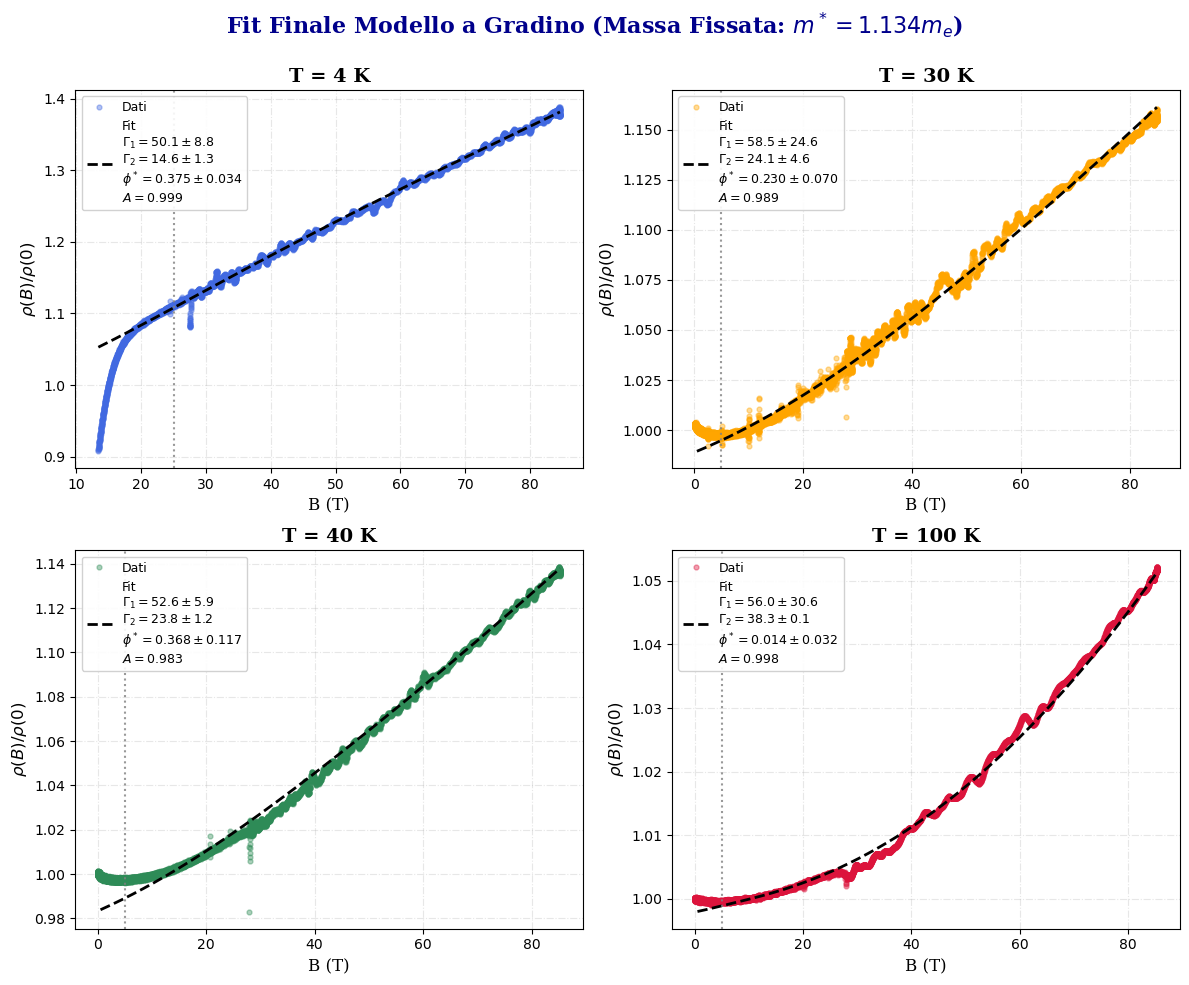

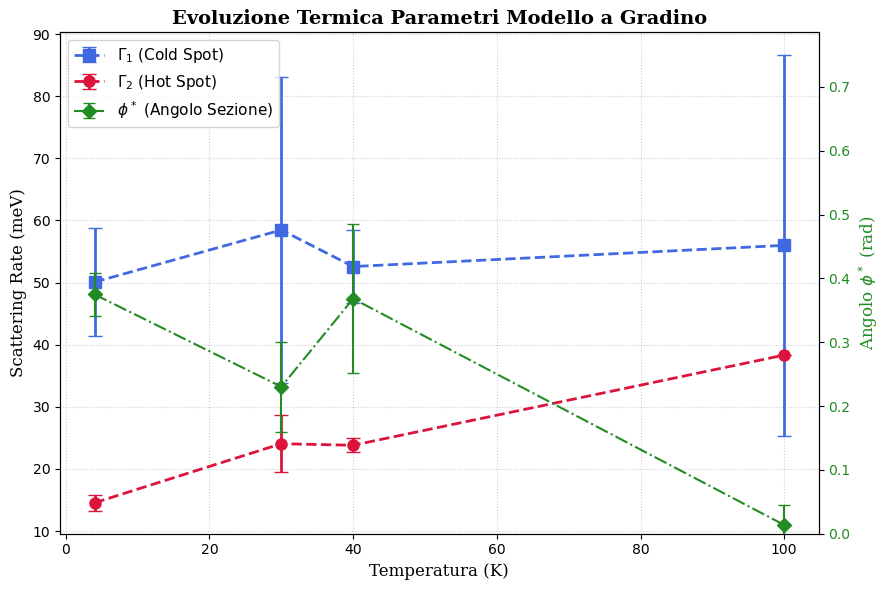

In [18]:
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}

DATA_BRUTE = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_BRUTE], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_BRUTE]) for T in T_LIST}
DATA_FINAL = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_FINAL], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_FINAL]) for T in T_LIST}

# ====================================================================
# 1.5 PRE-CHECK VRAM (SPECIFICO PER IL MODELLO A GRADINO)
# ====================================================================
def check_vram_step_safe(limit_gb=None):
    if limit_gb is None:
        limit_gb = vram
    n_g1, n_g2, n_phi, n_a = len(g1_range), len(g2_range), len(phi_range), len(a_range)
    max_Nb = max(len(DATA_BRUTE[T][0]) for T in T_LIST)
    
    base_grid_size = n_g1 * n_g2 * n_phi * max_Nb
    bytes_base = 168 * base_grid_size 
    
    full_grid_size = n_g1 * n_g2 * n_phi * n_a * max_Nb
    bytes_full = 24 * full_grid_size
    
    available_gb = limit_gb - 0.5
    grid_gb = (bytes_base + bytes_full) / (1024**3)
    
    print(f"🔍 PRE-CHECK VRAM GRADINO (Budget Totale Scheda: ~{limit_gb:.1f} GB)")
    print(f"  ↳ Budget VRAM disponibile per la Griglia:   {available_gb:.2f} GB")
    print(f"  ↳ Costo VRAM della Griglia:                 {grid_gb:.2f} GB ({n_g1}x{n_g2}x{n_phi}x{n_a} nodi)")
    
    if grid_gb > available_gb:
        print("⛔" * 20)
        raise MemoryError(f"ERRORE CRITICO: La VRAM richiesta ({grid_gb:.2f} GB) supera il budget ({available_gb:.2f} GB)! "
                          f"Riduci la griglia o alza STEP_BRUTE.")
    print("✅ Check VRAM Superato! Avvio in sicurezza.\n")

check_vram_step_safe()

# ====================================================================
# INIZIALIZZAZIONE 5D ORTOGONALE
# ====================================================================
print("🚀 Inizializzazione VRAM GPU...")
g1_gpu  = cp.asarray(g1_range)[:, None, None, None, None]  # Asse 0
g2_gpu  = cp.asarray(g2_range)[None, :, None, None, None]  # Asse 1
phi_gpu = cp.asarray(phi_range)[None, None, :, None, None] # Asse 2
a_gpu   = cp.asarray(a_range)[None, None, None, :, None]   # Asse 3

# ====================================================================
# MOTORE CUDA: LA FUNZIONE A GRADINO VETTORIALIZZATA
# ====================================================================
def cp_sigma_xx_step(B_val, m_star):
    psi_gpu = cp.pi / 4.0 - phi_gpu
    w = cl.K_MEV * B_val / m_star
    w = cp.where(w == 0, 1e-12, w)
    
    S1 = 2.0 * phi_gpu / w   # tempo cold-spot (Gamma1)
    S2 = 2.0 * psi_gpu / w   # tempo hot-spot  (Gamma2)
    
    g1_w = g1_gpu + 1j * w
    g2_w = g2_gpu + 1j * w
    
    denom = 1.0 + 1j * cp.exp(-(g1_gpu * S1 + g2_gpu * S2))
    
    Z12 = ((1.0 - cp.exp(-g2_w * S2)) / denom) * (1.0/g2_w - 1.0/g1_w)
    Z21 = ((1.0 - cp.exp(-g1_w * S1)) / denom) * (1.0/g1_w - 1.0/g2_w)
    
    t1 = (1.0 - cp.exp(-g1_w * S1)) / 2.0
    t2 = (1.0 - cp.exp(-g2_w * S2)) / 2.0
    
    O_I1 = (4.0 / (g1_gpu**2 + w**2)) * (g1_gpu - 1j*w) * (phi_gpu + Z12 * w * t1)
    O_I2 = (4.0 / (g2_gpu**2 + w**2)) * (g2_gpu - 1j*w) * (psi_gpu + Z21 * w * t2)
    
    return cp.real(cp.conj(O_I1 + O_I2))

# ====================================================================
# 3. FASE 1: GRID SEARCH GPU (Cerca la Massa Universale Migliore)
# ====================================================================
best_grid_rms_tot = np.inf
best_m_star = None
best_grid_params = {}

pbar_mass = tqdm(masses_to_test, desc="🏎️ Scansione Masse", bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}",position=0)

for m_test in pbar_mass:
    current_m_rms_tot = 0.0
    temp_grid_params = {}
    
    for T in T_LIST:
        B_b, R_b = DATA_BRUTE[T]
        B_gpu = cp.asarray(B_b)[None, None, None, None, :]
        R_gpu = cp.asarray(R_b)[None, None, None, None, :]
        
        sig_stab = cp_sigma_xx_step(B_gpu, m_test)
        # B→0: w→0, exp(-g*S)→0, quindi sigma_xx → 4*phi/g1 + 4*psi/g2 (limite analitico).
        # B=1e-8 T è sufficientemente piccolo (w~1e-9 meV) da approssimarlo numericamente.
        B_zero = cp.array([1e-8])[None, None, None, None, :]
        sig_0 = cp_sigma_xx_step(B_zero, m_test)
        
        MR_theo = (sig_0 / sig_stab) - 1.0
        R_theo = a_gpu * (MR_theo + 1.0)
        
        diff = R_theo - R_gpu
        rms_grid = cp.sqrt(cp.mean(diff**2, axis=-1))
        
        flat_idx = int(cp.nanargmin(rms_grid))
        shape = (len(g1_range), len(g2_range), len(phi_range), len(a_range))
        idx_g1, idx_g2, idx_phi, idx_a = np.unravel_index(flat_idx, shape)
        
        best_node_rms = float(rms_grid[idx_g1, idx_g2, idx_phi, idx_a])
        if np.isnan(best_node_rms): best_node_rms = 1e6
            
        temp_grid_params[T] = [float(g1_range[idx_g1]), float(g2_range[idx_g2]), 
                               float(phi_range[idx_phi]), float(a_range[idx_a])]
        current_m_rms_tot += best_node_rms
        
        pbar_mass.set_postfix({'T': f'{T}K', 'RMS(T)': f'{best_node_rms:.4f}'})
        
    if current_m_rms_tot < best_grid_rms_tot:
        best_grid_rms_tot = current_m_rms_tot
        best_m_star       = m_test
        best_grid_params  = temp_grid_params.copy()
        
    pbar_mass.set_postfix({'m* Vinta': f'{best_m_star:.3f}' if best_m_star is not None else 'N/D'}, bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}")

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

# ====================================================================
# 4 & 5. FASE 2: POLISH INDIPENDENTE E COVARIANZA (MASSA BLOCCATA)
# ====================================================================
print(f"\n✅ Scansione GPU Terminata! Massa universale trovata e BLOCCATA a: m* = {best_m_star:.3f}")
print("⏳ Avvio Polish Genetico Indipendente e Calcolo Incertezze...")
t_start = time.time()

final_m_star = best_m_star 
fit_step_dict = {}
# NaN come valore sentinella: curve_fit non è riuscito a stimare l'errore
err_dict = {T: [np.nan, np.nan, np.nan, np.nan] for T in T_LIST}

min_g1, max_g1   = max(0.001, min(g1_range)), max(g1_range)
min_g2, max_g2   = max(0.001, min(g2_range)), max(g2_range)
min_phi, max_phi = min(phi_range), max(phi_range)
min_a, max_a     = min(a_range), max(a_range)

bnds_local = [(min_g1, max_g1), (min_g2, max_g2), (min_phi, max_phi), (min_a, max_a)]
bounds_cf  = ([min_g1, min_g2, min_phi, min_a], [max_g1, max_g2, max_phi, max_a])

pbar_polish = tqdm(T_LIST, desc="Polish Indipendente (Gradino)", bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}")
eps = 1e-5

for T in pbar_polish:
    pbar_polish.set_postfix({'T': f'{T}K'})
    B_, R_exp = DATA_FINAL[T]
    
    x0_raw = best_grid_params[T]
    x0_guess = [
        np.clip(x0_raw[0], min_g1 + eps, max_g1 - eps),
        np.clip(x0_raw[1], min_g2 + eps, max_g2 - eps),
        np.clip(x0_raw[2], min_phi + eps, max_phi - eps),
        np.clip(x0_raw[3], min_a   + eps, max_a   - eps)
    ]
    
    def objective_local(p):
        G1, G2, phi, A = p
        if G1 <= 0 or G2 <= 0 or phi <= 0: return 1e6
        try:
            MR_theo = cl.mr_step(B_, G1, G2, phi, final_m_star)
            R_theo = A * (MR_theo + 1.0)
            if not np.all(np.isfinite(R_theo)): return 1e6
            return np.mean((R_theo - R_exp)**2)
        except Exception:
            return 1e6

    res_local = differential_evolution(
        objective_local, bounds=bnds_local, x0=x0_guess,          
        strategy='best1bin', popsize=5, maxiter=500, tol=1e-5,             
        mutation=(0.05, 0.2), recombination=0.9, polish=True,          
        workers=-1, updating='deferred'
    )
    
    G1_opt, G2_opt, phi_opt, A_opt = res_local.x
    
    R_theo = A_opt * (cl.mr_step(B_, G1_opt, G2_opt, phi_opt, final_m_star) + 1.0)
    resid_T = float(np.sqrt(np.mean((R_theo - R_exp)**2)))
    fit_step_dict[T] = (G1_opt, G2_opt, phi_opt, A_opt, resid_T)
    
    def local_fit_func(B_val, g1, g2, ph, a):
        return a * (cl.mr_step(B_val, g1, g2, ph, final_m_star) + 1.0)
    
    try:
        x0_cf = [
            np.clip(G1_opt,  min_g1 + eps, max_g1 - eps),
            np.clip(G2_opt,  min_g2 + eps, max_g2 - eps),
            np.clip(phi_opt, min_phi + eps, max_phi - eps),
            np.clip(A_opt,   min_a + eps, max_a - eps)
        ]
        popt, pcov = curve_fit(local_fit_func, B_, R_exp, p0=x0_cf, bounds=bounds_cf)
        err_dict[T] = list(np.sqrt(np.diag(pcov)))
    except Exception:
        pass  # err_dict[T] rimane NaN: segnalato nel report sotto

print(f"✅ Polish Indipendente completato in {time.time() - t_start:.1f} sec.")

# --------------------------------------------------------------------
# C) REPORT QUALITA' ERRORI
# --------------------------------------------------------------------
param_names = ["Gamma_1", "Gamma_2", "phi*", "A"]
for T in T_LIST:
    params = fit_step_dict[T][:4]
    errs = err_dict[T]
    for i in range(3):
        if np.isnan(errs[i]):
            print(f"  ⚠️ {param_names[i]} a {T}K: curve_fit fallito, errore non stimato.")
        elif errs[i] > params[i]:
            print(f"  ⚠️ {param_names[i]} a {T}K: incertezza ({errs[i]:.2f}) >> valore ({params[i]:.2f}) — parametro mal vincolato dal fit.")

# ====================================================================
# 6. FASE 3: GENERAZIONE 
# ====================================================================
font1 = {'family': 'serif', 'color':  'black', 'weight': 'bold', 'size': 14}
font2 = {'family': 'serif', 'color':  'black', 'weight': 'normal', 'size': 12}
plot_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}

# -- PLOT 1: Curve Magnetoresistenza (Gradino) --
fig1, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
fig1.suptitle(f"Fit Finale Modello a Gradino (Massa Fissata: $m^* = {final_m_star:.3f} m_e$)", 
             fontsize=16, fontweight='bold', fontfamily='serif', color='darkblue', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G1, G2, phi, A, _ = fit_step_dict[T]
    e_g1, e_g2, e_phi, e_A = err_dict[T]
    
    B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
    R_fit = A * (cl.mr_step(B_plot, G1, G2, phi, final_m_star) + 1.0)
    
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati")
    
    # Inseriamo phi* nella legenda del plot classico
    label_fit = (f"Fit\n$\\Gamma_{{1}}={G1:.1f} \\pm {e_g1:.1f}$\n"
                 f"$\\Gamma_{{2}}={G2:.1f} \\pm {e_g2:.1f}$\n"
                 f"$\\phi^*={phi:.3f} \\pm {e_phi:.3f}$\n"
                 f"$A={A:.3f}$")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    
    if T in B_MIN:
        ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8)
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.3)

fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# -- PLOT 2: Scattering e Angolo vs Temperatura --
T_array = np.array(T_LIST)
G1_array = np.array([fit_step_dict[T][0] for T in T_LIST])
G2_array = np.array([fit_step_dict[T][1] for T in T_LIST])
phi_array = np.array([fit_step_dict[T][2] for T in T_LIST])

err_g1 = np.array([err_dict[T][0] for T in T_LIST])
err_g2 = np.array([err_dict[T][1] for T in T_LIST])
err_phi = np.array([err_dict[T][2] for T in T_LIST])

fig2, ax1 = plt.subplots(figsize=(9, 6))

# Asse Sinistro: Gamma (meV)
ax1.errorbar(T_array, G1_array, yerr=err_g1, fmt='s--', color='royalblue', 
             markersize=8, linewidth=2, capsize=5, label=r'$\Gamma_1$ (Cold Spot)')
ax1.errorbar(T_array, G2_array, yerr=err_g2, fmt='o--', color='crimson', 
             markersize=8, linewidth=2, capsize=5, label=r'$\Gamma_2$ (Hot Spot)')
ax1.set_xlabel("Temperatura (K)", fontdict=font2)
ax1.set_ylabel("Scattering Rate (meV)", fontdict=font2, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle=':', alpha=0.6)

# Asse Destro: Phi (rad)
ax2 = ax1.twinx() 
ax2.errorbar(T_array, phi_array, yerr=err_phi, fmt='D-.', color='forestgreen', 
             markersize=7, linewidth=1.5, capsize=4, label=r'$\phi^*$ (Angolo Sezione)')
ax2.set_ylabel("Angolo $\phi^*$ (rad)", fontdict=font2, color='forestgreen')
ax2.tick_params(axis='y', labelcolor='forestgreen')
ax2.set_ylim(0, np.pi/4) # Limite fisico naturale per phi*

# Uniamo le legende
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title("Evoluzione Termica Parametri Modello a Gradino", fontdict=font1)
plt.tight_layout()
plt.show()

In [8]:
# ====================================================================
# ESPLORATORE INTERATTIVO (GRADINO) CON PANNELLO TERMODINAMICO E LIMITI ADATTIVI
# ====================================================================
def create_interactive_explorer_step_full():
    # 1. Menu a tendina per la Temperatura
    T_selector = widgets.Dropdown(
        options=T_LIST, 
        value=T_LIST[0], 
        description='Temp (K):'
    )

    # 2. Slider per i parametri (Limiti belli larghi per testare la disuguaglianza)
    m_slider   = widgets.FloatSlider(value=final_m_star, min=1.0, max=2.5, step=0.01, description='m* (m_e)', continuous_update=False)
    G1_slider  = widgets.FloatSlider(value=fit_step_dict[T_LIST[0]][0], min=0.01, max=200.0, step=0.5, description='Gamma_1', continuous_update=False)
    G2_slider  = widgets.FloatSlider(value=fit_step_dict[T_LIST[0]][1], min=0.01, max=300.0, step=1.0, description='Gamma_2', continuous_update=False)
    phi_slider = widgets.FloatSlider(value=fit_step_dict[T_LIST[0]][2], min=0.01, max=np.pi/4 - 0.001, step=0.01, description='phi*', continuous_update=False)
    A_slider   = widgets.FloatSlider(value=fit_step_dict[T_LIST[0]][3], min=0.6, max=1.3, step=0.005, description='A', continuous_update=False)
    
    # 3. Aggiorna gli slider se cambi Temperatura
    def on_T_change(change):
        T = change['new']
        G1_slider.value  = fit_step_dict[T][0]
        G2_slider.value  = fit_step_dict[T][1]
        phi_slider.value = fit_step_dict[T][2]
        A_slider.value   = fit_step_dict[T][3]

    T_selector.observe(on_T_change, names='value')

    # 4. Funzione di disegno in tempo reale 
    def plot_update(T, m_star, G1, G2, phi, A):
        B, R = DATA[T]
        B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
        
        # Calcolo Curva Teorica (GRADINO)
        R_fit = A * (cl.mr_step(B_plot, G1, G2, phi, m_star) + 1.0)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # =========================================================
        # PANNELLO 1: CURVA DI MAGNETORESISTENZA
        # =========================================================
        ax1.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=5, alpha=0.6, label="Dati Sperimentali")
        
        label_fit = (f"Curva Teorica\n$m^*$: {m_star:.3f}\n"
                     f"$\Gamma_1$: {G1:.1f} meV\n"
                     f"$\Gamma_2$: {G2:.1f} meV\n"
                     f"$\phi^*$: {phi:.3f} rad\n"
                     f"$A$: {A:.3f}")
        ax1.plot(B_plot, R_fit, "k-", linewidth=2.5, label=label_fit)

        if T in B_MIN:
            ax1.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
            ax1.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)

        ax1.set_xlabel("B (T)", fontdict=font2)
        ax1.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
        ax1.set_title(f"MR (Gradino) - T = {T} K", fontdict=font1)
        ax1.legend(fontsize=11, loc="upper left", framealpha=0.9)
        ax1.grid(linestyle="-.", alpha=0.4)
        
        # Limiti Adattivi 
        min_y, max_y = min(np.min(R), np.min(R_fit)), max(np.max(R), np.max(R_fit))
        pad_y = (max_y - min_y) * 0.05
        if pad_y == 0: pad_y = 0.1 
        ax1.set_ylim(min_y - pad_y, max_y + pad_y)
        ax1.set_xlim(min(B.min(), B_plot.min()) * 0.9, B.max() * 1.05)
        
        # =========================================================
        # PANNELLO 2: TERMODINAMICA GAMMA (IN TEMPO REALE)
        # =========================================================
        T_array = np.array(T_LIST)
        
        G1_array, G2_array = [], []
        for t_val in T_LIST:
            if t_val == T:
                G1_array.append(G1)  # Valore mosso dallo slider
                G2_array.append(G2)  # Valore mosso dallo slider
            else:
                G1_array.append(fit_step_dict[t_val][0]) # Valore Fissato
                G2_array.append(fit_step_dict[t_val][1]) # Valore Fissato
                
        err_g1_arr = np.array([err_dict[t][0] for t in T_LIST])
        err_g2_arr = np.array([err_dict[t][1] for t in T_LIST])

        ax2.errorbar(T_array, G1_array, yerr=err_g1_arr, fmt='s--', 
                     color='royalblue', markersize=7, linewidth=2, capsize=5, capthick=1.5, 
                     label=r'Sezione 1 ($\Gamma_1$)')
        ax2.errorbar(T_array, G2_array, yerr=err_g2_arr, fmt='o--', 
                     color='crimson', markersize=7, linewidth=2, capsize=5, capthick=1.5, 
                     label=r'Sezione 2 ($\Gamma_2$)')

        # Evidenziatore
        ax2.axvline(T, color='green', linestyle=':', alpha=0.6, linewidth=2, label=f'Stai modificando T={T}K')
        ax2.plot(T, G1, 's', color='cyan', markersize=12, markeredgecolor='black', zorder=5)
        ax2.plot(T, G2, 'o', color='yellow', markersize=12, markeredgecolor='black', zorder=5)

        ax2.set_title("Evoluzione Termica Interattiva", fontdict=font1)
        ax2.set_xlabel("Temperatura (K)", fontdict=font2)
        ax2.set_ylabel("Scattering Rate (meV)", fontdict=font2)
        ax2.set_xticks(T_array)
        ax2.legend(fontsize=10, loc='best')
        ax2.grid(True, linestyle=':', alpha=0.7)
        
        max_gamma = max(max(G1_array), max(G2_array))
        ax2.set_ylim(-2, max(80.0, max_gamma * 1.1))

        plt.tight_layout()
        plt.show()

    # 5. UI Layout
    out = widgets.interactive_output(plot_update, {
        'T': T_selector, 'm_star': m_slider, 'G1': G1_slider, 'G2': G2_slider, 'phi': phi_slider, 'A': A_slider
    })

    ui = widgets.VBox([
        widgets.HBox([T_selector, m_slider]),
        widgets.HBox([G1_slider, G2_slider, phi_slider, A_slider])
    ])
    
    display(ui, out)

create_interactive_explorer_step_full()

Output()

# Fit con T-dependence esplicito
Modello Bessel: 
* $\Gamma_i = a_iT^p + c_i$  con $\ p = 0,1,2$
 
In questo modo i fit saranno obbligati a ritornare una ben definita T-dependence di $\Gamma$

## Modello Bessel $cos^4$

In [59]:
#start, end, step
#attenzione perche step troppo alti superano il limite di VRAM della GPU
masses_to_test = np.linspace(0.9, 2.01, 100) 
g_is_range = np.linspace(0.0, 50.0, 50)      
g_an_range = np.linspace(0.0, 50.0, 50)      
a_range    = np.linspace(0.9, 1.1, 10)  

STEP_BRUTE = 100
STEP_FINAL = 10 

USE_BESSEL_CACHE = True  # True = Velocissimo (< 30 masse, usa molta VRAM), False = On-The-Fly (> 30 masse, VRAM sicura)
t_max = 30; s_max = 3; mu_max = 15

In [60]:
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
DATA_BRUTE = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_BRUTE], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_BRUTE]) for T in T_LIST}
DATA_FINAL = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_FINAL], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_FINAL]) for T in T_LIST}
s_arr = np.arange(-s_max, s_max + 1)
N_all = np.concatenate([2*s_arr, 2*s_arr + 1])
mu_arr = np.arange(-mu_max, mu_max + 1)
N_abs = int(np.max(np.abs(N_all)))
k_al = np.arange(0, t_max + 2*mu_max + 2*N_abs + 1)
k_al8 = np.arange(0, mu_max + N_abs + 1)
ns = len(s_arr)

# ====================================================================
# 1.5 PRE-CHECK VRAM INTELLIGENTE E ADATTIVO (BESSEL)
# ====================================================================
def check_vram_bessel_adaptive(limit_gb=None):
    # limit_gb letto a runtime così non dipende dall'ordine di esecuzione delle celle
    if limit_gb is None:
        limit_gb = vram
    n_Gis, n_Gan, n_A = len(g_is_range), len(g_an_range), len(a_range)
    n_t = 2 * t_max + 1
    max_Nb = max(len(DATA_BRUTE[T][0]) for T in T_LIST)
    max_Nw = max_Nb + n_Gan 

    bytes_cache = 0
    if USE_BESSEL_CACHE:
        size_I_al = len(k_al) * n_Gan * max_Nw * 8
        size_I_al8 = len(k_al8) * n_Gan * max_Nw * 8
        size_omega = max_Nw * 8
        bytes_per_node = size_I_al + size_I_al8 + size_omega
        bytes_cache = bytes_per_node * len(masses_to_test) * len(T_LIST)
        
    cache_gb = bytes_cache / (1024**3)
    available_gb = limit_gb - cache_gb 
    
    bytes_inner_loop = (16 + 8 + 16 + 16) * n_Gis * n_Gan * max_Nw * n_t
    bytes_rms = (8 + 8 + 8) * n_A * n_Gis * n_Gan * max_Nb
    
    if not USE_BESSEL_CACHE:
        size_I_al = len(k_al) * n_Gan * max_Nw * 8
        size_I_al8 = len(k_al8) * n_Gan * max_Nw * 8
        bytes_inner_loop += (size_I_al + size_I_al8)

    grid_gb = (bytes_inner_loop + bytes_rms) / (1024**3)
    
    print(f"🔍 PRE-CHECK VRAM ADATTIVO (Budget Totale Scheda: ~{limit_gb:.1f} GB)")
    print(f"  ↳ Modalità Scelta: {'ATTIVA ⚡ (Max Velocità)' if USE_BESSEL_CACHE else 'ON-THE-FLY 🐢 (Risparmio VRAM)'}")
    
    if USE_BESSEL_CACHE:
        print(f"  ↳ Spazio bloccato dalla Cache Bessel: {cache_gb:.2f} GB")
        print(f"  ↳ Budget VRAM disponibile per la Griglia:   {available_gb:.2f} GB")
    else:
        print(f"  ↳ Budget VRAM disponibile per la Griglia:   {available_gb:.2f} GB")
        
    print(f"  ↳ Costo VRAM della Griglia:       {grid_gb:.2f} GB ({n_Gis}x{n_Gan}x{n_A} nodi)")

    if grid_gb > available_gb:
        print("⛔" * 20)
        if USE_BESSEL_CACHE:
            raise MemoryError(f"ERRORE CRITICO: La Cache ({cache_gb:.2f} GB) più la Griglia ({grid_gb:.2f} GB) "
                              f"superano la memoria fisica della scheda!\n"
                              f"Soluzione Immediata: Imposta USE_BESSEL_CACHE = False per liberare la VRAM bloccata.")
        else:
            raise MemoryError(f"ERRORE CRITICO: Il costo della Griglia ({grid_gb:.2f} GB) supera il budget disponibile ({available_gb:.2f} GB)!\n"
                              f"Soluzioni: Alza STEP_BRUTE (es. da 100 a 200) o diminuisci i punti di g_is_range/g_an_range.")
    print("✅ Check VRAM Superato! I calcoli rientrano nel budget. Avvio...\n")

check_vram_bessel_adaptive()

# ====================================================================
# 2. PRE-CALCOLO COSTANTI GPU E (OPZIONALE) CACHE
# ====================================================================
print(f"🚀 Inizializzazione GPU...")
s_arr_gpu = cp.asarray(s_arr)
N_all_gpu = cp.asarray(N_all)
mu_arr_gpu = cp.asarray(mu_arr)
sign_s_gpu = cp.asarray((-1.0) ** s_arr)
sign_mu_gpu = cp.asarray((-1.0) ** mu_arr)
sign_t_gpu  = cp.asarray((-1.0) ** np.arange(-t_max, t_max + 1))
t_an_gpu    = cp.asarray(np.arange(-t_max, t_max + 1) * 4 + 1, dtype=cp.float64)
g_is_gpu    = cp.asarray(g_is_range)
g_an_gpu    = cp.asarray(g_an_range)
a_range_gpu = cp.asarray(a_range)
n_Gis = len(g_is_range); n_Gan = len(g_an_range); n_A = len(a_range)

BESSEL_CACHE_DICT = {}
if USE_BESSEL_CACHE:
    for m in tqdm(masses_to_test, desc="📦 Caching Bessel in VRAM", bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}",leave=False):
        BESSEL_CACHE_DICT[m] = {}
        for T in T_LIST:
            B_b, _ = DATA_BRUTE[T]
            B_refs = np.array([cl._B_ref_bessel(ga, m) for ga in g_an_range])
            B_all = np.concatenate([B_b, B_refs])
            omega_all = cl.com_omega(B_all, m)
            omega_gpu = cp.asarray(omega_all)
            alpha_gpu = g_an_gpu[:, None] / (8.0 * omega_gpu[None, :])
            
            I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)     
            I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu/8.0) 
            
            BESSEL_CACHE_DICT[m][T] = (I_al_gpu, I_al8_gpu, omega_gpu)

# ====================================================================
# 3. FASE 1: SCANSIONE GPU IBRIDA
# ====================================================================
best_grid_rms_tot = np.inf
best_m_star = None
best_grid_params = {}

pbar_mass = tqdm(masses_to_test, desc="🏎️ Scansione Masse", position=0, bar_format="{desc} {percentage:3.0f}%  |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}")

for m_test in pbar_mass:
    current_m_rms_tot = 0.0
    temp_grid_params = {}
    
    with tqdm(T_LIST, desc=f"  ↳ Analisi m*={m_test:.2f}", position=1, leave=False, bar_format="{desc} {percentage:3.0f}% 🚀 |{bar}| {n_fmt}/{total_fmt} [⏱️ {elapsed}-⏳ {remaining}] {postfix}") as pbar_T:
        for T in pbar_T:
            B_b, R_b = DATA_BRUTE[T]
            Nb = len(B_b)
            R_b_gpu = cp.asarray(R_b)
            
            if USE_BESSEL_CACHE:
                I_al_gpu, I_al8_gpu, omega_gpu = BESSEL_CACHE_DICT[m_test][T]
            else:
                B_refs = np.array([cl._B_ref_bessel(ga, m_test) for ga in g_an_range])
                B_all = np.concatenate([B_b, B_refs])
                omega_all = cl.com_omega(B_all, m_test)
                omega_gpu = cp.asarray(omega_all)
                alpha_gpu = g_an_gpu[:, None] / (8.0 * omega_gpu[None, :])
                I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)     
                I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu/8.0) 
            
            omega_t = omega_gpu[None, :] * t_an_gpu[:, None]
            
            iv_mu_al8  = I_al8_gpu[cp.abs(mu_arr_gpu), :, :]
            iv_muN_al8 = I_al8_gpu[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :, :]
            
            sum_s_c_arr = cp.zeros((2*t_max + 1, n_Gan, len(omega_gpu)), dtype=complex)
            
            for t_idx, t in enumerate(range(-t_max, t_max + 1)):
                iv_tm_al  = I_al_gpu[cp.abs(t - 2*mu_arr_gpu), :, :]
                iv_tmN_al = I_al_gpu[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :, :]
                A_mu = sign_mu_gpu[:, None, None] * iv_tm_al * iv_mu_al8
                zeta_all = cp.einsum('mgb,mngb,mngb->ngb', A_mu, iv_tmN_al, iv_muN_al8)
                sum_s_c_arr[t_idx] = cp.sum(
                    sign_s_gpu[:, None, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0
                )
                
            G_tilde   = g_is_gpu[:, None] + 3 * g_an_gpu[None, :] / 8.0
            prefactor = G_tilde[:, :, None, None] - 1j * omega_t[None, None, :, :]
            denom     = G_tilde[:, :, None, None]**2 + omega_t[None, None, :, :]**2
            
            ssc      = sum_s_c_arr.transpose(1, 0, 2)
            inner_c  = prefactor * ssc[None, :, :, :]
            weighted = sign_t_gpu[None, None, :, None] * inner_c / denom
            temp_vec = cp.sum(weighted, axis=2)
            
            sigma_all_vec = cp.real(cp.conj(cp.pi * temp_vec))
            sig_stab_vec  = sigma_all_vec[:, :, :Nb]
            gan_idx       = cp.arange(n_Gan)
            sig0_vec      = sigma_all_vec[:, gan_idx, Nb + gan_idx]
            MR_theo_vec   = sig0_vec[:, :, None] / sig_stab_vec - 1.0
            
            R_theo   = a_range_gpu[:, None, None, None] * (MR_theo_vec + 1.0)[None, :, :, :]
            diff     = R_theo - R_b_gpu[None, None, None, :]
            rms_grid = cp.sqrt(cp.mean(diff**2, axis=3))
            
            flat_idx = int(cp.nanargmin(rms_grid))
            i_A   = flat_idx // (n_Gis * n_Gan)
            rem   = flat_idx %  (n_Gis * n_Gan)
            i_Gis = rem // n_Gan
            i_Gan = rem %  n_Gan
            
            best_node_rms = float(rms_grid[i_A, i_Gis, i_Gan])
            if np.isnan(best_node_rms): best_node_rms = 1e6
                
            temp_grid_params[T] = [float(g_is_range[i_Gis]), float(g_an_range[i_Gan]), float(a_range[i_A])]
            current_m_rms_tot += best_node_rms
            
            pbar_T.set_postfix({'RMS': f'{best_node_rms:.4f}'})
            
            del prefactor, denom, inner_c, weighted, R_theo, diff, rms_grid, sum_s_c_arr, sigma_all_vec
            if not USE_BESSEL_CACHE:
                del I_al_gpu, I_al8_gpu
            gc.collect()
            cp.get_default_memory_pool().free_all_blocks()
    
    if current_m_rms_tot < best_grid_rms_tot:
        best_grid_rms_tot = current_m_rms_tot
        best_m_star       = m_test
        best_grid_params  = temp_grid_params.copy()
    
    pbar_mass.set_postfix({
        'm* Vinta': f'{best_m_star:.3f}' if best_m_star is not None else 'N/D',
        'RMS Tot': f'{best_grid_rms_tot:.4f}'
    })

gc.collect()
cp.get_default_memory_pool().free_all_blocks()
final_m_star = best_m_star
print(f"\n✅ Massa universale BLOCCATA a: m* = {final_m_star:.3f}")

🔍 PRE-CHECK VRAM ADATTIVO (Budget Totale Scheda: ~8.0 GB)
  ↳ Modalità Scelta: ATTIVA ⚡ (Max Velocità)
  ↳ Spazio bloccato dalla Cache Bessel: 1.52 GB
  ↳ Budget VRAM disponibile per la Griglia:   6.44 GB
  ↳ Costo VRAM della Griglia:       0.86 GB (50x50x10 nodi)
✅ Check VRAM Superato! I calcoli rientrano nel budget. Avvio...

🚀 Inizializzazione GPU...


📦 Caching Bessel in VRAM   0% 🚀 |          | 0/100 [⏱️ 00:00-⏳ ?] 

🏎️ Scansione Masse   0%  |          | 0/100 [⏱️ 00:00-⏳ ?] 

  ↳ Analisi m*=0.90   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

  ↳ Analisi m*=0.91   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

...

  ↳ Analisi m*=1.98   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

  ↳ Analisi m*=1.99   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

  ↳ Analisi m*=2.00   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 

  ↳ Analisi m*=2.01   0% 🚀 |          | 0/4 [⏱️ 00:00-⏳ ?] 


✅ Massa universale BLOCCATA a: m* = 2.010


In [61]:
# ════════════════════════════════════════════════════════════════════
# PARAMETRI FIT — modifica qui per cambiare modello e tuning
# ════════════════════════════════════════════════════════════════════

# ── Scelta del modello ──────────────────────────────────────────────
MODEL = "linear"     # "linear" oppure "mir"

# ── Bounds parametri (per modello) ──────────────────────────────────
BOUNDS = {
    "linear": [
        (0.0, 20.0),   # G_is_0    [meV]   isotropo a T=0
        (-0.5,   0.5),   # alpha_is  [meV/K] rate isotropo
        (0.0, 40.0),   # G_an_0    [meV]   anisotropo a T=0
        (-0.5,  0.5),   # alpha_an  [meV/K] rate anisotropo
    ],
    "mir": [
        (0., 70.0), # G_sat     [meV]   tetto saturazione MIR
        (0.01,   20.0),  # G_is_0    [meV]
        (0.0,     0.5),  # alpha_is  [meV/K]
        (0.0,    40.0),  # G_an_0    [meV]
        (0.0,     0.5),  # alpha_an  [meV/K]
    ],
}

# ── GPU LHS scan ────────────────────────────────────────────────────
N_GUESSES        = 5_000   # punti LHS pool
BATCH_SIZE_SCAN  = 1_300   # batch GPU (riduci se OOM)
N_STARTS         =    30   # top candidati GPU → multi-start L-BFGS-B

# ── Parallelizzazione CPU (multi-start L-BFGS-B) ────────────────────
# None  → usa os.cpu_count() - 1 (pesta tutta la CPU)
# 0.5   → metà dei core (CPU respira, OS resta reattivo)
# int N → esattamente N processi
N_JOBS = None

# ── Tolleranze L-BFGS-B ─────────────────────────────────────────────
LBFGS_MAXITER = 500
LBFGS_FTOL    = 1e-10
LBFGS_GTOL    = 1e-7

assert MODEL in BOUNDS, f"MODEL deve essere 'linear' o 'mir', ricevuto {MODEL!r}"
print(f"✅ Configurazione caricata — modello: '{MODEL}', dim={len(BOUNDS[MODEL])}")


✅ Configurazione caricata — modello: 'linear', dim=4


⏳ Avvio Fit unificato — modello: 'linear'  |  m* bloccata = 2.010
🔍 PRE-CHECK VRAM SUPER-SCANNER (Budget Totale Scheda: ~7.5 GB)
  ↳ Cache Bessel (cella 16) ancora in VRAM: 1.43 GB
  ↳ Budget disponibile per il Super-Scanner:  6.03 GB
  ↳ Costo stimato per BATCH_SIZE_SCAN=1300:
     • I_al + I_al8:               0.398 GB
     • iv_mu_al8 + iv_muN_al8:     1.193 GB  (persistenti)
     • picco loop-t (A+iv+B+prod): 3.361 GB  (temporanei)
     ─────────────────────────────────────────────
     • Totale picco:                4.951 GB
✅ Check VRAM Superato! (batch sicuro fino a 1583) Avvio...

⚙️  GPU Scan LHS: 5000 candidati (4D), batch=1300


🔥 GPU Scan LHS:   0%|          | 0/16 [00:00<?, ?batch/s]


✅ Primo batch OK — CuPy operativo.


✅ GPU Scan: 80.3 sec
⏳ Multi-start L-BFGS-B su top-30 candidati...
  ↳ Parallelizzazione su 23/24 core CPU (N_JOBS=None)


🎯 Multi-start L-BFGS-B:   0%|          | 0/30 [00:00<?, ?start/s]

/tmp/ipykernel_2344/4206335601.py:62: RuntimeWarning: overflow encountered in dot
/tmp/ipykernel_2344/4206335601.py:62: RuntimeWarning: overflow encountered in dot



✅ Fit 'linear' completato in 111.9 sec.
  ↳ Γ_is(T) = 7.411 + 0.1315·T  meV
  ↳ Γ_an(T) = 38.338 + -0.3539·T  meV
  ↳ Loss pesato: 1.41e-03
  ↳ RMS relativo per temperatura:
     T=    4 K | RMSE=4.5123e-03 | ampiezza MR=0.3041 | rel=1.48%
     T=   30 K | RMSE=4.7145e-03 | ampiezza MR=0.1663 | rel=2.83%
     T=   40 K | RMSE=2.1122e-03 | ampiezza MR=0.1417 | rel=1.49%
     T=  100 K | RMSE=6.7758e-04 | ampiezza MR=0.0528 | rel=1.28%


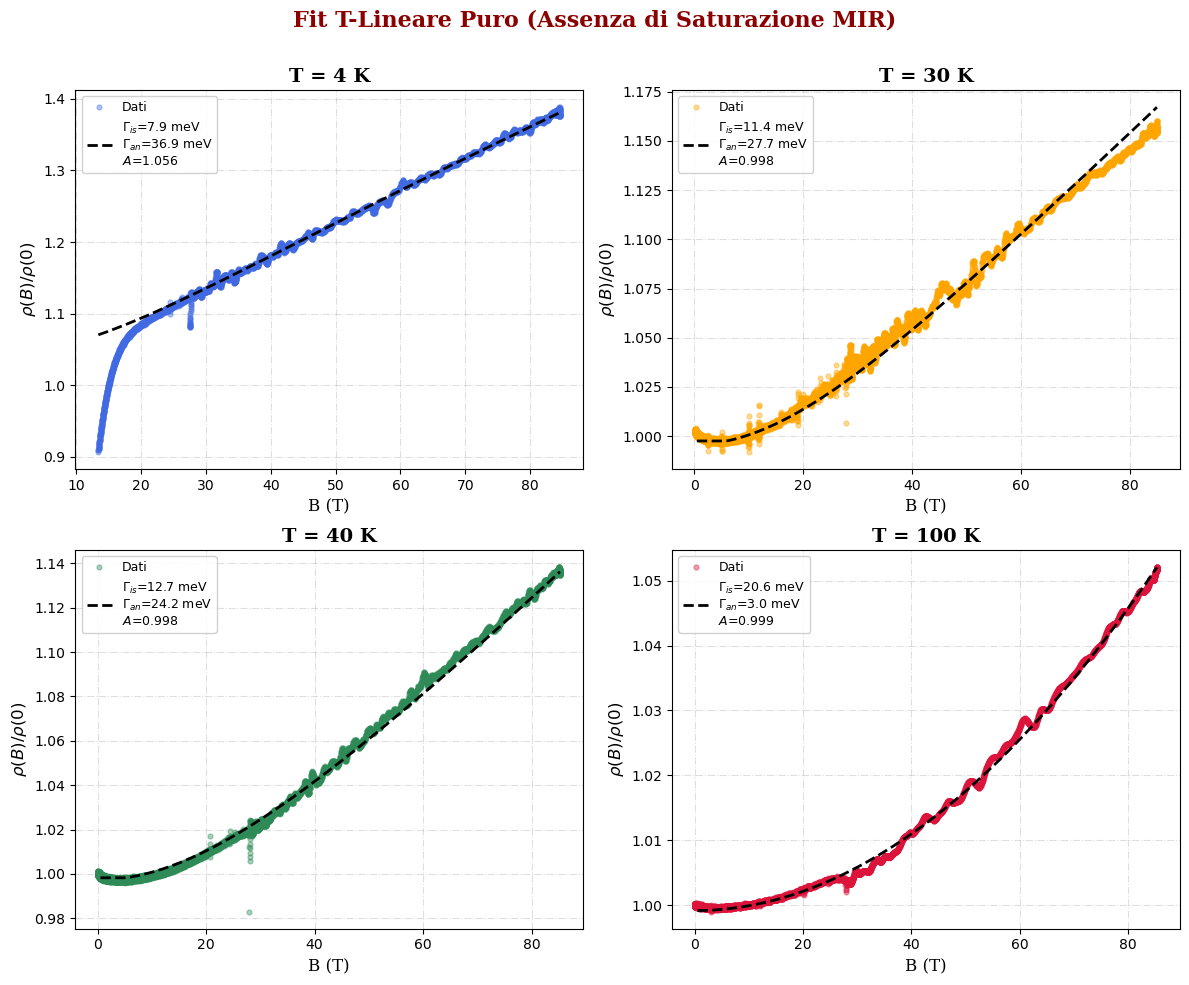

### 📊 Equazioni Estratte — Regime Strange Metal (T-Lineare Puro)
Nessuna saturazione Mott-Ioffe-Regel osservata. Leggi di scattering (in meV):

$$ \Gamma_{is}(T) = 7.41 + 0.132 \cdot T $$

$$ \Gamma_{an}(T) = 38.34 + -0.354 \cdot T $$

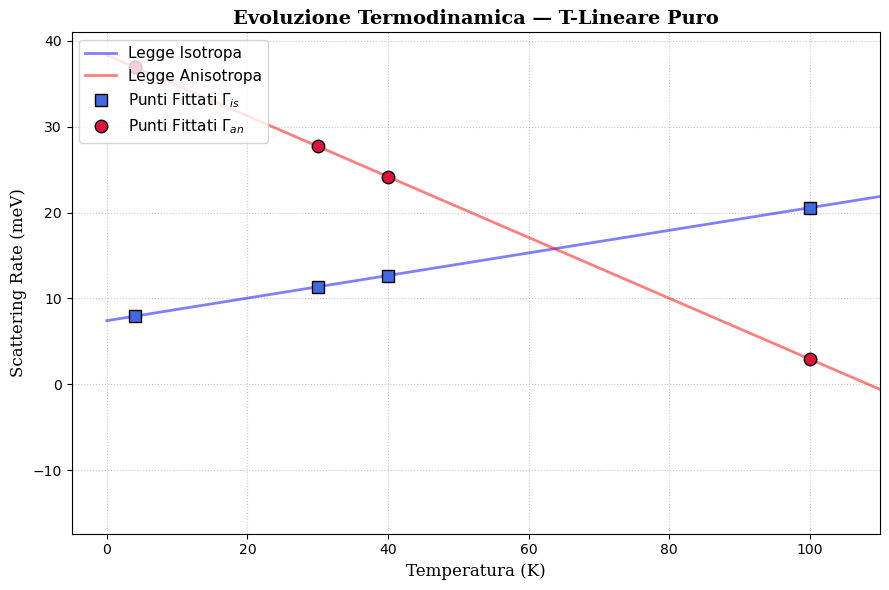

In [62]:
# ════════════════════════════════════════════════════════════════════
# FIT UNIFICATO (linear o mir secondo MODEL)
# ════════════════════════════════════════════════════════════════════
import time, os, sys
from scipy.optimize import minimize as sp_minimize
from scipy.stats.qmc import LatinHypercube, scale as qmc_scale
from joblib import Parallel, delayed
from IPython.display import display, Markdown

t_start_total = time.time()
print(f"⏳ Avvio Fit unificato — modello: '{MODEL}'  |  m* bloccata = {final_m_star:.3f}")

# ── Helpers comuni ──────────────────────────────────────────────────
def model_gamma(T, params):
    """Restituisce (G_is_T, G_an_T) in meV per scalari NumPy."""
    if MODEL == "linear":
        G_is_0, alpha_is, G_an_0, alpha_an = params
        return (G_is_0 + alpha_is * T, G_an_0 + alpha_an * T)
    else:  # "mir"
        G_sat, G_is_0, alpha_is, G_an_0, alpha_an = params
        G_id_is = G_is_0 + alpha_is * T
        G_id_an = G_an_0 + alpha_an * T
        return ((G_id_is * G_sat) / (G_id_is + G_sat),
                (G_id_an * G_sat) / (G_id_an + G_sat))

def model_gamma_gpu_batch(T, sample_gpu):
    """Restituisce (G_is_full, G_an_full) come array CuPy (N_GUESSES,)."""
    if MODEL == "linear":
        GI0, AI, GA0, AA = sample_gpu
        return (GI0 + AI * T, GA0 + AA * T)
    else:  # "mir"
        GS, GI0, AI, GA0, AA = sample_gpu
        G_id_is = GI0 + AI * T
        G_id_an = GA0 + AA * T
        return ((G_id_is * GS) / (G_id_is + GS),
                (G_id_an * GS) / (G_id_an + GS))

def safe_MR_Bessel_Array(B_val, gi, ga, m_s):
    B_val = np.atleast_1d(B_val).astype(float)
    b_ref = cl._B_ref_bessel(ga, m_s)
    sig0  = cl.sigma_xx_Bessel(np.array([b_ref]), gi, ga, m_s)[0]
    out   = np.zeros_like(B_val)
    mask  = B_val >= b_ref
    if mask.any():
        sig_stab  = cl.sigma_xx_Bessel(B_val[mask], gi, ga, m_s)
        out[mask] = (sig0 / sig_stab) - 1.0
    return out

# Pesi per-T per bilanciare il loss tra alte e basse temperature
_W_T = {T: 1.0 / max(np.ptp(DATA_FINAL[T][1]) ** 2, 1e-6) for T in T_LIST}

def objective(p):
    total = 0.0
    for T in T_LIST:
        G_is_T, G_an_T = model_gamma(T, p)
        B_, R_exp = DATA_FINAL[T]
        try:
            MR = safe_MR_Bessel_Array(B_, G_is_T, G_an_T, final_m_star)
            F  = MR + 1.0
            if not np.all(np.isfinite(F)) or np.all(MR == 0):
                return 1e6
            A      = np.dot(F, R_exp) / np.dot(F, F)
            total += _W_T[T] * np.mean((A * F - R_exp) ** 2)
        except:
            return 1e6
    return total

# ── Pre-check VRAM ──────────────────────────────────────────────────
check_vram_superscan()

# ── FASE 1: GPU LHS pool scan ───────────────────────────────────────
DIM = len(BOUNDS[MODEL])
lo  = [b[0] for b in BOUNDS[MODEL]]
hi  = [b[1] for b in BOUNDS[MODEL]]

print(f"⚙️  GPU Scan LHS: {N_GUESSES} candidati ({DIM}D), batch={BATCH_SIZE_SCAN}")
t0 = time.time()
_lhs       = LatinHypercube(d=DIM, seed=42).random(n=N_GUESSES)
_sample    = qmc_scale(_lhs, lo, hi)               # (N_GUESSES, DIM)
sample_gpu = [cp.asarray(_sample[:, d]) for d in range(DIM)]

total_error_gpu = cp.zeros(N_GUESSES, dtype=cp.float64)
tot_batches = len(T_LIST) * -(-N_GUESSES // BATCH_SIZE_SCAN)
pbar_gpu = tqdm(total=tot_batches, desc="🔥 GPU Scan LHS",  unit="batch", colour="#a855f7")

for T in T_LIST:
    B_cpu, R_cpu = DATA_FINAL[T]
    B_gpu_t = cp.asarray(B_cpu, dtype=cp.float64)
    R_gpu_t = cp.asarray(R_cpu, dtype=cp.float64)
    G_is_full, G_an_full = model_gamma_gpu_batch(T, sample_gpu)

    for i in range(0, N_GUESSES, BATCH_SIZE_SCAN):
        end = min(i + BATCH_SIZE_SCAN, N_GUESSES)
        MR_batch = compute_batch_MR_Bessel_GPU_v2(
            B_gpu_t, G_is_full[i:end], G_an_full[i:end], final_m_star)

        if i == 0 and T == T_LIST[0]:
            print("\n✅ Primo batch OK — CuPy operativo.\n")

        MR_batch = cp.where(cp.isnan(MR_batch) | (MR_batch < 0), 0.0, MR_batch)
        F_theo   = MR_batch + 1.0
        A_opt    = cp.sum(F_theo * R_gpu_t, axis=1) / cp.sum(F_theo**2, axis=1)
        err = cp.mean((A_opt[:, cp.newaxis] * F_theo - R_gpu_t)**2, axis=1)
        err = cp.where(cp.all(MR_batch == 0.0, axis=1), 1e6, err)
        total_error_gpu[i:end] += _W_T[T] * err   # peso per-T anche nello scan
        pbar_gpu.update(1)

    cp.get_default_memory_pool().free_all_blocks()

pbar_gpu.colour = "#10b981"
pbar_gpu.set_description("✅ GPU Scan Completato!")
pbar_gpu.close()
print(f"\n✅ GPU Scan: {time.time()-t0:.1f} sec")
cp.get_default_memory_pool().free_all_blocks()

# ── FASE 2: Multi-start L-BFGS-B parallelo dai top candidati ────────
top_idx = cp.argsort(total_error_gpu)[:N_STARTS].get()
x0_list = [_sample[idx].copy() for idx in top_idx]

print(f"⏳ Multi-start L-BFGS-B su top-{N_STARTS} candidati...")
t1 = time.time()
_n_cpu = os.cpu_count() or 1
if N_JOBS is None:
    n_jobs = max(1, _n_cpu - 1)
elif isinstance(N_JOBS, float):
    n_jobs = max(1, int(round(_n_cpu * N_JOBS)))
else:
    n_jobs = max(1, min(int(N_JOBS), _n_cpu))
print(f"  ↳ Parallelizzazione su {n_jobs}/{_n_cpu} core CPU (N_JOBS={N_JOBS})")

def _run_local(x0):
    return sp_minimize(objective, x0, method='L-BFGS-B', bounds=BOUNDS[MODEL],
                       options={'maxiter': LBFGS_MAXITER,
                                'ftol':    LBFGS_FTOL,
                                'gtol':    LBFGS_GTOL})

results = Parallel(n_jobs=n_jobs, backend='loky')(
    delayed(_run_local)(x0) for x0 in tqdm(x0_list,
                                            desc="🎯 Multi-start L-BFGS-B",
                                            unit="start", colour="#3b82f6")
)
best_res = min(results, key=lambda r: r.fun)
best_val = best_res.fun
time.sleep(0.5)
# ── Pausa di "respiro" prima dei risultati finali ───────────────────
sys.stdout.flush()
time.sleep(0.5)

# ── Risultati e diagnostica ─────────────────────────────────────────
p_opt = best_res.x
time.sleep(0.5)
print(f"\n✅ Fit '{MODEL}' completato in {time.time() - t_start_total:.1f} sec.")

if MODEL == "linear":
    G_is_0_opt, alpha_is_opt, G_an_0_opt, alpha_an_opt = p_opt
    print(f"  ↳ Γ_is(T) = {G_is_0_opt:.3f} + {alpha_is_opt:.4f}·T  meV")
    print(f"  ↳ Γ_an(T) = {G_an_0_opt:.3f} + {alpha_an_opt:.4f}·T  meV")
else:
    G_sat_opt, G_is_0_opt, alpha_is_opt, G_an_0_opt, alpha_an_opt = p_opt
    print(f"  ↳ Γ_sat globale: {G_sat_opt:.1f} meV")
    print(f"  ↳ Γ_is_0={G_is_0_opt:.3f} meV, α_is={alpha_is_opt:.4f} meV/K")
    print(f"  ↳ Γ_an_0={G_an_0_opt:.3f} meV, α_an={alpha_an_opt:.4f} meV/K")
print(f"  ↳ Loss pesato: {best_val:.2e}")

print("  ↳ RMS relativo per temperatura:")
fit_results = {}
for T in T_LIST:
    G_is_T, G_an_T = model_gamma(T, p_opt)
    B_, R_exp = DATA_FINAL[T]
    MR = safe_MR_Bessel_Array(B_, G_is_T, G_an_T, final_m_star)
    F  = MR + 1.0
    A  = np.dot(F, R_exp) / np.dot(F, F)
    rmse_abs = np.sqrt(np.mean((A * F - R_exp) ** 2))
    amp_mr   = np.ptp(R_exp)
    print(f"     T={T:>5.0f} K | RMSE={rmse_abs:.4e} | ampiezza MR={amp_mr:.4f} | rel={rmse_abs/amp_mr*100:.2f}%")
    fit_results[T] = (G_is_T, G_an_T, float(A), 0.0)

# ════════════════════════════════════════════════════════════════════
# PLOT
# ════════════════════════════════════════════════════════════════════
font1 = {'family': 'serif', 'color': 'black', 'weight': 'bold',   'size': 14}
font2 = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}
plot_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}

# ── Pannello MR(B) per ogni T ──────────────────────────────────────
fig1, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
title1 = (f"Fit MIR (Saturazione a $\\Gamma_{{sat}}$={G_sat_opt:.1f} meV)" if MODEL == "mir"
          else "Fit T-Lineare Puro (Assenza di Saturazione MIR)")
fig1.suptitle(title1, fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G_is, G_an, A, _ = fit_results[T]
    B_plot  = np.linspace(max(B.min(), 0.5), B.max(), 60)
    R_fit   = A * (safe_MR_Bessel_Array(B_plot, G_is, G_an, final_m_star) + 1.0)
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati")
    label_fit = f"$\\Gamma_{{is}}$={G_is:.1f} meV\n$\\Gamma_{{an}}$={G_an:.1f} meV\n$A$={A:.3f}"
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)
if len(T_LIST) < 4:
    axs.flatten()[-1].axis('off')
fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# ── Equazioni in markdown ──────────────────────────────────────────
if MODEL == "linear":
    mkd = (f"### 📊 Equazioni Estratte — Regime Strange Metal (T-Lineare Puro)\n"
           f"Nessuna saturazione Mott-Ioffe-Regel osservata. Leggi di scattering (in meV):\n\n"
           f"$$ \\Gamma_{{is}}(T) = {G_is_0_opt:.2f} + {alpha_is_opt:.3f} \\cdot T $$\n\n"
           f"$$ \\Gamma_{{an}}(T) = {G_an_0_opt:.2f} + {alpha_an_opt:.3f} \\cdot T $$")
else:
    mkd = (f"### 📊 Equazioni Estratte — Saturazione Mott-Ioffe-Regel\n"
           f"Limite di saturazione strutturale: **$\\Gamma_{{sat}} = {G_sat_opt:.1f}$ meV**.\n\n"
           f"$$ \\Gamma_{{is}}(T) = \\frac{{({G_is_0_opt:.2f} + {alpha_is_opt:.3f}\\,T) \\cdot {G_sat_opt:.1f}}}"
           f"{{({G_is_0_opt:.2f} + {alpha_is_opt:.3f}\\,T) + {G_sat_opt:.1f}}} $$\n\n"
           f"$$ \\Gamma_{{an}}(T) = \\frac{{({G_an_0_opt:.2f} + {alpha_an_opt:.3f}\\,T) \\cdot {G_sat_opt:.1f}}}"
           f"{{({G_an_0_opt:.2f} + {alpha_an_opt:.3f}\\,T) + {G_sat_opt:.1f}}} $$")
display(Markdown(mkd))

# ── Curve Γ vs T ───────────────────────────────────────────────────
T_smooth    = np.linspace(0, 150, 100)
G_is_smooth = np.array([model_gamma(t, p_opt)[0] for t in T_smooth])
G_an_smooth = np.array([model_gamma(t, p_opt)[1] for t in T_smooth])
T_array  = np.array(T_LIST)
G_is_pts = np.array([fit_results[T][0] for T in T_LIST])
G_an_pts = np.array([fit_results[T][1] for T in T_LIST])

fig2, ax = plt.subplots(figsize=(9, 6))
if MODEL == "linear":
    ax.plot(T_smooth, G_is_smooth, 'b-', alpha=0.5, linewidth=2, label="Legge Isotropa")
    ax.plot(T_smooth, G_an_smooth, 'r-', alpha=0.5, linewidth=2, label="Legge Anisotropa")
    title2 = "Evoluzione Termodinamica — T-Lineare Puro"
    leg_loc = 'upper left'
else:
    ax.plot(T_smooth, G_is_smooth, 'b-', alpha=0.5, linewidth=2, label="Curva Saturazione $\\Gamma_{is}$")
    ax.plot(T_smooth, G_an_smooth, 'r-', alpha=0.5, linewidth=2, label="Curva Saturazione $\\Gamma_{an}$")
    title2 = "Evoluzione Termodinamica — Saturazione MIR"
    leg_loc = 'lower right'
ax.plot(T_array, G_is_pts, 's', color='royalblue', markersize=9, markeredgecolor='black', label="Punti Fittati $\\Gamma_{is}$")
ax.plot(T_array, G_an_pts, 'o', color='crimson',   markersize=9, markeredgecolor='black', label="Punti Fittati $\\Gamma_{an}$")
ax.set_title(title2, fontdict=font1)
ax.set_xlabel("Temperatura (K)", fontdict=font2)
ax.set_ylabel("Scattering Rate (meV)", fontdict=font2)
ax.legend(fontsize=11, loc=leg_loc)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlim(-5, max(110, max(T_LIST) + 10))
if MODEL == "mir":
    ax.set_ylim(-1, max(G_an_pts) + 10)
plt.tight_layout()
plt.show()


## Step Model

In [45]:
# ════════════════════════════════════════════════════════════════════
# PARAMETRI FIT — Step Model
#   MODEL_S     : T-dipendenza di Gamma1/Gamma2  ('linear' | 'mir')
#   PHI_MODEL_S : T-dipendenza di phi*           ('const' | 'linear' | 'tanh')
# I bounds di phi* vengono appesi in coda a quelli di Gamma.
# ════════════════════════════════════════════════════════════════════

MODEL_S     = "linear"  # 'linear' o 'mir'
PHI_MODEL_S = "const"    # 'const' | 'linear' | 'tanh'

PHI_LIM = np.pi/4 - 1e-3   # limite superiore per phi* [rad] ≈ 0.784

# ── Bounds per la T-dipendenza di Gamma (indipendenti da PHI_MODEL_S) ──
_GAMMA_BOUNDS_S = {
    "linear": [
        (0.01,  50.0),    # G1_0  [meV]   cold-spot a T=0
        (0.0,    0.5),    # a1    [meV/K] slope cold
        (0.01,  50.0),    # G2_0  [meV]   hot-spot a T=0
        (0.0,    0.5),    # a2    [meV/K] slope hot
    ],
    "mir": [
        (40.0, 150.0),    # G_sat [meV]   tetto saturazione MIR
        (0.01,  25.0),    # G1_0  [meV]
        (0.0,    0.5),    # a1    [meV/K]
        (0.01,  50.0),    # G2_0  [meV]
        (0.0,    0.5),    # a2    [meV/K]
    ],
}

# ── Bounds per phi*(T) (appesi in coda) ────────────────────────────
#   'const' : phi0
#   'linear': phi0, beta [rad/K]   — phi*(T) = phi0 + beta*T
#   'tanh'  : phi0, dphi, T_phi   — phi*(T) = phi0 + dphi*tanh(T/T_phi)
_PHI_BOUNDS_S = {
    "const": [
        (0.01, PHI_LIM),         # phi0 [rad]
    ],
    "linear": [
        (0.01, PHI_LIM),         # phi0 [rad]   valore a T=0
        (-7e-3, 7e-3),           # beta [rad/K] (pi/4 / 100 K ≈ 7.9e-3)
    ],
    "tanh": [
        (0.01, PHI_LIM),         # phi0 [rad]   valore a T=0
        (-PHI_LIM, PHI_LIM),     # dphi [rad]   variazione asintotica
        (50.0, 500.0),            # T_phi [K]    scala termica
    ],
}

BOUNDS_S = _GAMMA_BOUNDS_S[MODEL_S] + _PHI_BOUNDS_S[PHI_MODEL_S]

N_GUESSES_S       = 20_000
BATCH_SIZE_SCAN_S = 10_000
N_STARTS_S        =    100
N_JOBS_S          =    None
LBFGS_MAXITER_S   =    500
LBFGS_FTOL_S      =  1e-10
LBFGS_GTOL_S      =   1e-7

# B_MIN per temperatura [T] — nessuna divergenza Bessel, si può abbassare liberamente
B_MIN_S = {4.0: 25.0, 30.0: 5.0, 40.0: 1.0, 100.0: 1.0}

DATA_STEP = {}
for T in T_LIST:
    B_all, R_all = DATA[T]
    bmin = B_MIN_S.get(T, 0.5)
    m = B_all >= bmin
    DATA_STEP[T] = (B_all[m], R_all[m])
    print(f"T={T:>5.0f} K : {m.sum():4d} punti (B >= {bmin} T)")

assert MODEL_S in _GAMMA_BOUNDS_S,   f"MODEL_S sconosciuto: {MODEL_S!r}"
assert PHI_MODEL_S in _PHI_BOUNDS_S, f"PHI_MODEL_S sconosciuto: {PHI_MODEL_S!r}"
_dg = len(_GAMMA_BOUNDS_S[MODEL_S])
_dp = len(_PHI_BOUNDS_S[PHI_MODEL_S])
print(f"\n✅ Step config — Γ: '{MODEL_S}' ({_dg}D) + φ*: '{PHI_MODEL_S}' ({_dp}D) = tot {_dg+_dp}D")


T=    4 K : 2973 punti (B >= 25.0 T)
T=   30 K : 5276 punti (B >= 5.0 T)
T=   40 K : 7535 punti (B >= 1.0 T)
T=  100 K : 7474 punti (B >= 1.0 T)

✅ Step config — Γ: 'linear' (4D) + φ*: 'const' (1D) = tot 5D


⏳ Avvio Fit step — Γ: 'linear'  φ*: 'const'  |  m* = 1.500
⚙️  GPU Scan LHS step: 20000 candidati (5D), batch=10000


🔥 GPU Scan Step:   0%|          | 0/8 [00:00<?, ?batch/s]


✅ Primo batch OK — step model GPU operativo.


✅ GPU Scan: 27.4 sec
⏳ Multi-start L-BFGS-B su top-100 candidati step...
  ↳ 23/24 core CPU  (N_JOBS_S=None)


🎯 L-BFGS-B step:   0%|          | 0/100 [00:00<?, ?start/s]


✅ Fit step 'linear' + φ* 'const' completato in 33.8 sec.
  ↳ Γ₁(T) = 9.288 + 0.1876·T  [cold-spot]
  ↳ Γ₂(T) = 29.660 + 0.0000·T  [hot-spot]
  ↳ φ* = 0.3985 rad = 22.83° (costante)
  ↳ Loss pesato: 1.38e-03
  ↳ RMSE relativo per temperatura:
     T=    4 K | RMSE=4.5549e-03 | amp=0.3066 | rel=1.49% | φ*=22.83°
     T=   30 K | RMSE=3.8244e-03 | amp=0.1679 | rel=2.28% | φ*=22.83°
     T=   40 K | RMSE=3.5242e-03 | amp=0.1552 | rel=2.27% | φ*=22.83°
     T=  100 K | RMSE=6.0379e-04 | amp=0.0531 | rel=1.14% | φ*=22.83°


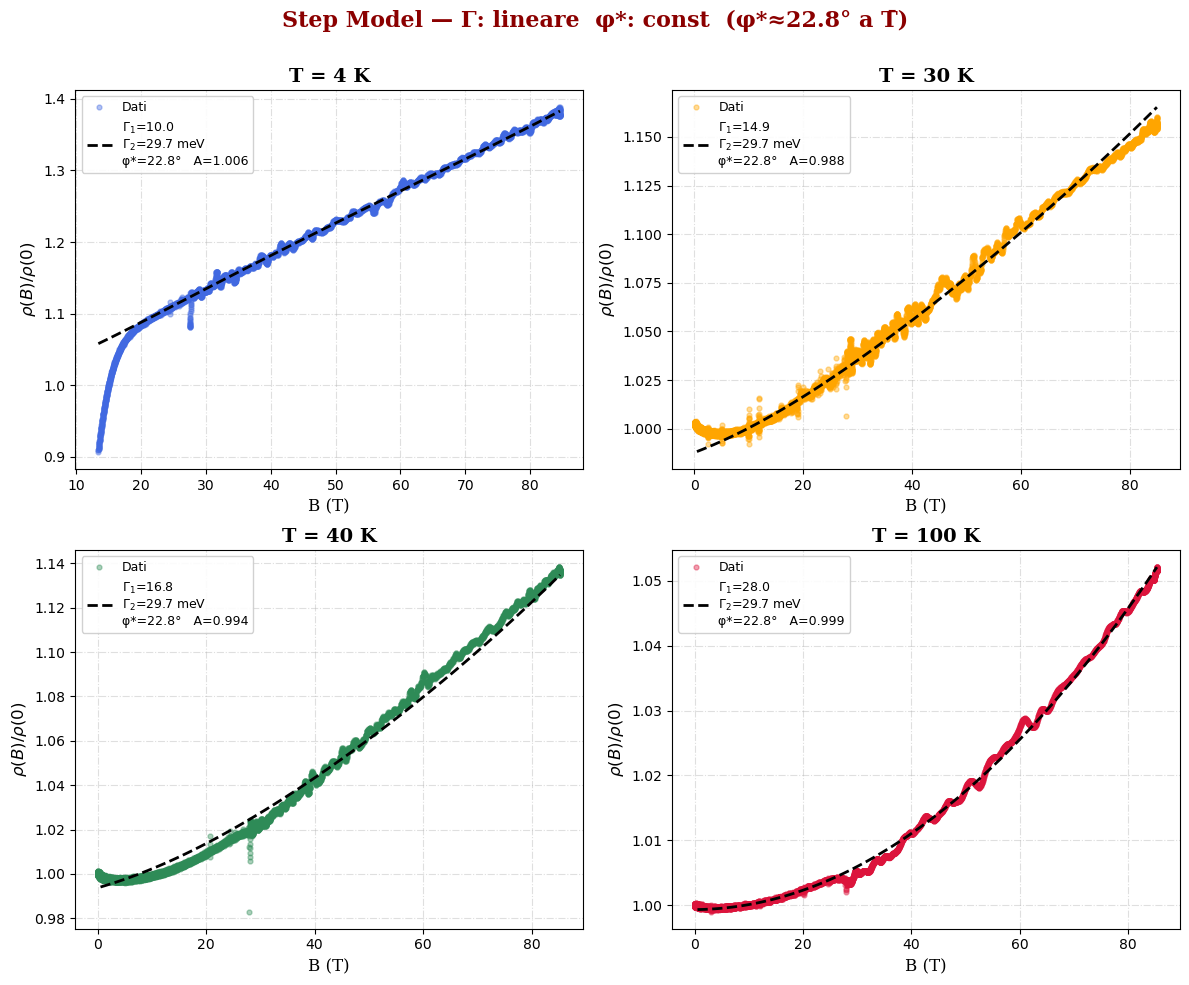

### Step Model — Γ: linear   φ*: const

$$ \Gamma_1(T) = 9.29 + 0.188\,T $$ (cold-spot)

$$ \Gamma_2(T) = 29.66 + 0.000\,T $$ (hot-spot)

$$ \varphi^* = 22.83^\circ \text{ (costante)} $$

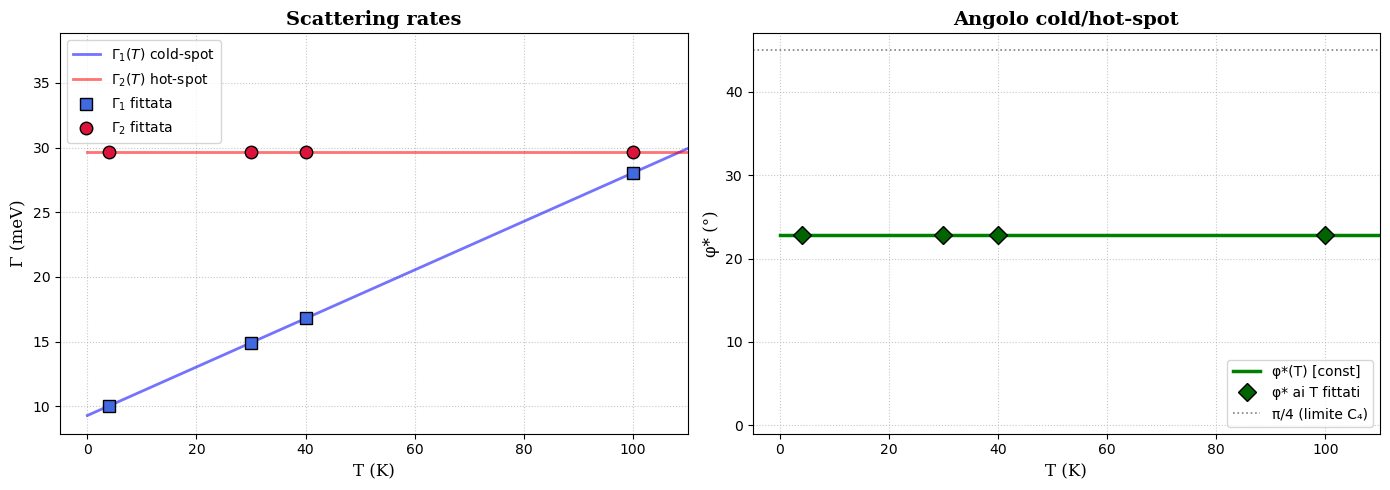

In [46]:
# ════════════════════════════════════════════════════════════════════
# FIT STEP MODEL — Gamma: MODEL_S, phi*: PHI_MODEL_S
# ════════════════════════════════════════════════════════════════════
import time, os, sys
from scipy.optimize import minimize as sp_minimize
from scipy.stats.qmc import LatinHypercube, scale as qmc_scale
from joblib import Parallel, delayed
from IPython.display import display, Markdown

t_start_total = time.time()
print(f"⏳ Avvio Fit step — Γ: '{MODEL_S}'  φ*: '{PHI_MODEL_S}'  |  m* = {final_m_star:.3f}")

# ── Engine GPU ────────────────────────────────────────────────────────
def compute_batch_MR_step_GPU(B_gpu, G1_batch, G2_batch, phi_batch, m_star):
    K_loc = 0.116
    G1  = G1_batch[:, None];  G2  = G2_batch[:, None]
    phi = phi_batch[:, None]; psi = cp.pi / 4.0 - phi
    w   = (K_loc / m_star) * B_gpu[None, :]
    S1  = 2.0 * phi / w;      S2  = 2.0 * psi / w
    exp1  = cp.exp(-(G1 + 1j * w) * S1)
    exp2  = cp.exp(-(G2 + 1j * w) * S2)
    denom = 1.0 + 1j * cp.exp(-(G1 * S1 + G2 * S2))
    inv1  = 1.0 / (G1 + 1j * w);  inv2 = 1.0 / (G2 + 1j * w)
    Z12   = (1.0 - exp2) / denom * (inv2 - inv1)
    Z21   = (1.0 - exp1) / denom * (inv1 - inv2)
    t1_c  = (1.0 - exp1) * 0.5;   t2_c = (1.0 - exp2) * 0.5
    OI1   = (4.0 / (G1**2 + w**2)) * (G1 - 1j * w) * (phi + Z12 * w * t1_c)
    OI2   = (4.0 / (G2**2 + w**2)) * (G2 - 1j * w) * (psi + Z21 * w * t2_c)
    sig_xx = cp.real(OI1 + OI2)
    sig0   = 4.0 * (phi_batch / G1_batch + (cp.pi / 4.0 - phi_batch) / G2_batch)
    return sig0[:, None] / sig_xx - 1.0

# ── phi*(T): CPU scalare e GPU batch ─────────────────────────────────
def _n_gamma():  return len(_GAMMA_BOUNDS_S[MODEL_S])

def eval_phi_cpu(T, phi_p):
    if PHI_MODEL_S == "const":
        val = phi_p[0]
    elif PHI_MODEL_S == "linear":
        val = phi_p[0] + phi_p[1] * T
    else:  # tanh
        val = phi_p[0] + phi_p[1] * np.tanh(T / max(float(phi_p[2]), 1e-3))
    return float(np.clip(val, 1e-3, np.pi / 4 - 1e-3))

def eval_phi_gpu(T, phi_smp):
    if PHI_MODEL_S == "const":
        val = phi_smp[0]
    elif PHI_MODEL_S == "linear":
        val = phi_smp[0] + phi_smp[1] * T
    else:  # tanh
        val = phi_smp[0] + phi_smp[1] * cp.tanh(T / cp.maximum(phi_smp[2], 1e-3))
    return cp.clip(val, 1e-3, cp.pi / 4 - 1e-3)

# ── T-dipendenza completa: CPU ────────────────────────────────────────
def model_gamma_step(T, params):
    ng    = _n_gamma()
    phi_T = eval_phi_cpu(T, params[ng:])
    if MODEL_S == "linear":
        G10, a1, G20, a2 = params[:ng]
        return G10 + a1 * T, G20 + a2 * T, phi_T
    else:
        Gs, G10, a1, G20, a2 = params[:ng]
        G1i = G10 + a1 * T;  G2i = G20 + a2 * T
        return G1i * Gs / (G1i + Gs), G2i * Gs / (G2i + Gs), phi_T

# ── T-dipendenza completa: GPU batch ─────────────────────────────────
def model_gamma_step_gpu(T, smp):
    ng    = _n_gamma()
    phi_T = eval_phi_gpu(T, smp[ng:])
    if MODEL_S == "linear":
        G10, A1, G20, A2 = smp[:ng]
        return G10 + A1 * T, G20 + A2 * T, phi_T
    else:
        GS, G10, A1, G20, A2 = smp[:ng]
        G1i = G10 + A1 * T;  G2i = G20 + A2 * T
        return G1i * GS / (G1i + GS), G2i * GS / (G2i + GS), phi_T

_W_T_S = {T: 1.0 / max(np.ptp(DATA_STEP[T][1]) ** 2, 1e-6) for T in T_LIST}

def objective_step(p):
    total = 0.0
    for T in T_LIST:
        G1_T, G2_T, phi_T = model_gamma_step(T, p)
        B_, R_exp = DATA_STEP[T]
        try:
            MR = cl.mr_step(B_, G1_T, G2_T, phi_T, final_m_star)
            F  = MR + 1.0
            if not np.all(np.isfinite(F)) or np.all(MR == 0):
                return 1e6
            A      = np.dot(F, R_exp) / np.dot(F, F)
            total += _W_T_S[T] * np.mean((A * F - R_exp) ** 2)
        except:
            return 1e6
    return total

# ── FASE 1: GPU LHS scan ─────────────────────────────────────────────
DIM_S = len(BOUNDS_S)
lo_s  = [b[0] for b in BOUNDS_S]
hi_s  = [b[1] for b in BOUNDS_S]

print(f"⚙️  GPU Scan LHS step: {N_GUESSES_S} candidati ({DIM_S}D), batch={BATCH_SIZE_SCAN_S}")
t0 = time.time()
_lhs_s    = LatinHypercube(d=DIM_S, seed=42).random(n=N_GUESSES_S)
_sample_s = qmc_scale(_lhs_s, lo_s, hi_s)
sample_gpu_s = [cp.asarray(_sample_s[:, d]) for d in range(DIM_S)]

total_error_gpu_s = cp.zeros(N_GUESSES_S, dtype=cp.float64)
tot_batches_s = len(T_LIST) * -(-N_GUESSES_S // BATCH_SIZE_SCAN_S)
pbar_s = tqdm(total=tot_batches_s, desc="🔥 GPU Scan Step", unit="batch", colour="#a855f7")

for T in T_LIST:
    B_cpu, R_cpu = DATA_STEP[T]
    B_gpu_t = cp.asarray(B_cpu, dtype=cp.float64)
    R_gpu_t = cp.asarray(R_cpu, dtype=cp.float64)
    G1_full, G2_full, phi_full = model_gamma_step_gpu(T, sample_gpu_s)

    for i in range(0, N_GUESSES_S, BATCH_SIZE_SCAN_S):
        end = min(i + BATCH_SIZE_SCAN_S, N_GUESSES_S)
        MR_batch = compute_batch_MR_step_GPU(
            B_gpu_t, G1_full[i:end], G2_full[i:end], phi_full[i:end], final_m_star)

        if i == 0 and T == T_LIST[0]:
            print("\n✅ Primo batch OK — step model GPU operativo.\n")

        MR_batch = cp.where(~cp.isfinite(MR_batch), 0.0, MR_batch)
        F_theo   = MR_batch + 1.0
        A_opt    = cp.sum(F_theo * R_gpu_t, axis=1) / cp.sum(F_theo ** 2, axis=1)
        err      = cp.mean((A_opt[:, cp.newaxis] * F_theo - R_gpu_t) ** 2, axis=1)
        err      = cp.where(~cp.isfinite(err), 1e6, err)
        total_error_gpu_s[i:end] += _W_T_S[T] * err
        pbar_s.update(1)

    cp.get_default_memory_pool().free_all_blocks()

pbar_s.colour = "#10b981"
pbar_s.set_description("✅ GPU Scan Step Completato!")
pbar_s.close()
print(f"\n✅ GPU Scan: {time.time() - t0:.1f} sec")

# ── FASE 2: Multi-start L-BFGS-B ─────────────────────────────────────
top_idx_s = cp.argsort(total_error_gpu_s)[:N_STARTS_S].get()
x0_list_s = [_sample_s[idx].copy() for idx in top_idx_s]

print(f"⏳ Multi-start L-BFGS-B su top-{N_STARTS_S} candidati step...")
t1 = time.time()
_n_cpu = os.cpu_count() or 1
if N_JOBS_S is None:
    n_jobs_s = max(1, _n_cpu - 1)
elif isinstance(N_JOBS_S, float):
    n_jobs_s = max(1, int(round(_n_cpu * N_JOBS_S)))
else:
    n_jobs_s = max(1, min(int(N_JOBS_S), _n_cpu))
print(f"  ↳ {n_jobs_s}/{_n_cpu} core CPU  (N_JOBS_S={N_JOBS_S})")

def _run_local_step(x0):
    return sp_minimize(objective_step, x0, method='L-BFGS-B', bounds=BOUNDS_S,
                       options={'maxiter': LBFGS_MAXITER_S,
                                'ftol':    LBFGS_FTOL_S,
                                'gtol':    LBFGS_GTOL_S})

results_s = Parallel(n_jobs=n_jobs_s, backend='loky')(
    delayed(_run_local_step)(x0) for x0 in tqdm(x0_list_s,
                                                  desc="🎯 L-BFGS-B step",
                                                  unit="start", colour="#3b82f6")
)
best_res_s = min(results_s, key=lambda r: r.fun)
p_opt_s    = best_res_s.x

sys.stdout.flush()
time.sleep(0.5)

# ── Risultati ─────────────────────────────────────────────────────────
ng = _n_gamma()
gamma_opt = p_opt_s[:ng]
phi_p_opt = p_opt_s[ng:]

print(f"\n✅ Fit step '{MODEL_S}' + φ* '{PHI_MODEL_S}' completato in {time.time()-t_start_total:.1f} sec.")
if MODEL_S == "linear":
    G10_opt, a1_opt, G20_opt, a2_opt = gamma_opt
    print(f"  ↳ Γ₁(T) = {G10_opt:.3f} + {a1_opt:.4f}·T  [cold-spot]")
    print(f"  ↳ Γ₂(T) = {G20_opt:.3f} + {a2_opt:.4f}·T  [hot-spot]")
else:
    Gsat_opt, G10_opt, a1_opt, G20_opt, a2_opt = gamma_opt
    print(f"  ↳ Γ_sat = {Gsat_opt:.1f} meV")
    print(f"  ↳ Γ₁_0={G10_opt:.3f}, α₁={a1_opt:.4f}  [cold-spot]")
    print(f"  ↳ Γ₂_0={G20_opt:.3f}, α₂={a2_opt:.4f}  [hot-spot]")

if PHI_MODEL_S == "const":
    print(f"  ↳ φ* = {phi_p_opt[0]:.4f} rad = {np.degrees(phi_p_opt[0]):.2f}° (costante)")
elif PHI_MODEL_S == "linear":
    print(f"  ↳ φ*(T) = {phi_p_opt[0]:.4f} + {phi_p_opt[1]:.5f}·T  rad")
    print(f"           = {np.degrees(phi_p_opt[0]):.2f}° + {np.degrees(phi_p_opt[1]):.4f}°/K · T")
else:  # tanh
    print(f"  ↳ φ*(T) = {phi_p_opt[0]:.4f} + {phi_p_opt[1]:.4f}·tanh(T/{phi_p_opt[2]:.1f} K)  rad")
    print(f"           φ*(0)={np.degrees(phi_p_opt[0]):.2f}°, "
          f"φ*(∞)={np.degrees(phi_p_opt[0]+phi_p_opt[1]):.2f}°, "
          f"T_φ={phi_p_opt[2]:.1f} K")

print(f"  ↳ Loss pesato: {best_res_s.fun:.2e}")

print("  ↳ RMSE relativo per temperatura:")
fit_results_s = {}
for T in T_LIST:
    G1_T, G2_T, phi_T = model_gamma_step(T, p_opt_s)
    B_, R_exp = DATA_STEP[T]
    MR  = cl.mr_step(B_, G1_T, G2_T, phi_T, final_m_star)
    F   = MR + 1.0
    A   = np.dot(F, R_exp) / np.dot(F, F)
    rms = np.sqrt(np.mean((A * F - R_exp) ** 2))
    amp = np.ptp(R_exp)
    print(f"     T={T:>5.0f} K | RMSE={rms:.4e} | amp={amp:.4f} | rel={rms/amp*100:.2f}%"
          f" | φ*={np.degrees(phi_T):.2f}°")
    fit_results_s[T] = (G1_T, G2_T, phi_T, float(A))

# ── PLOT 1: pannelli MR(B) ────────────────────────────────────────────
font1 = {'family': 'serif', 'color': 'black', 'weight': 'bold',   'size': 14}
font2 = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}
plot_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}

fig1, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
_phi_mid = np.degrees(eval_phi_cpu(np.mean(T_LIST), phi_p_opt))
fig1.suptitle(
    f"Step Model — Γ: {'MIR' if MODEL_S=='mir' else 'lineare'}  "
    f"φ*: {PHI_MODEL_S}  (φ*≈{_phi_mid:.1f}° a T̄)",
    fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G1, G2, phi_T, A = fit_results_s[T]
    B_plot = np.linspace(max(0.5, B[B > 0].min()), B.max(), 80)
    R_fit  = A * (cl.mr_step(B_plot, G1, G2, phi_T, final_m_star) + 1.0)
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati")
    lbl = (f"$\\Gamma_1$={G1:.1f}\n$\\Gamma_2$={G2:.1f} meV\n"
           f"φ*={np.degrees(phi_T):.1f}°   A={A:.3f}")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=lbl)
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)
fig1.tight_layout(); fig1.subplots_adjust(top=0.90)
plt.show()

# ── Equazioni markdown ────────────────────────────────────────────────
if MODEL_S == "linear":
    _eq_G1 = f"$$ \\Gamma_1(T) = {G10_opt:.2f} + {a1_opt:.3f}\\,T $$ (cold-spot)"
    _eq_G2 = f"$$ \\Gamma_2(T) = {G20_opt:.2f} + {a2_opt:.3f}\\,T $$ (hot-spot)"
else:
    _eq_G1 = (f"$$ \\Gamma_1(T) = \\frac{{({G10_opt:.2f}+{a1_opt:.3f}T)\\cdot{Gsat_opt:.0f}}}"
              f"{{({G10_opt:.2f}+{a1_opt:.3f}T)+{Gsat_opt:.0f}}} $$")
    _eq_G2 = (f"$$ \\Gamma_2(T) = \\frac{{({G20_opt:.2f}+{a2_opt:.3f}T)\\cdot{Gsat_opt:.0f}}}"
              f"{{({G20_opt:.2f}+{a2_opt:.3f}T)+{Gsat_opt:.0f}}} $$")
if PHI_MODEL_S == "const":
    _eq_phi = f"$$ \\varphi^* = {np.degrees(phi_p_opt[0]):.2f}^\\circ \\text{{ (costante)}} $$"
elif PHI_MODEL_S == "linear":
    _eq_phi = (f"$$ \\varphi^*(T) = {np.degrees(phi_p_opt[0]):.2f}^\\circ "
               f"+ {np.degrees(phi_p_opt[1]):.4f}^\\circ/\\text{{K}}\\cdot T $$")
else:
    _eq_phi = (f"$$ \\varphi^*(T) = {np.degrees(phi_p_opt[0]):.2f}^\\circ "
               f"+ {np.degrees(phi_p_opt[1]):.2f}^\\circ\\cdot"
               f"\\tanh\\!\\left(T/{phi_p_opt[2]:.1f}\\,\\text{{K}}\\right) $$")
display(Markdown(
    f"### Step Model — Γ: {MODEL_S}   φ*: {PHI_MODEL_S}\n\n"
    + _eq_G1 + "\n\n" + _eq_G2 + "\n\n" + _eq_phi
))

# ── PLOT 2: Γ(T) e φ*(T) ─────────────────────────────────────────────
T_smooth = np.linspace(0, 150, 200)
G1_sm  = np.array([model_gamma_step(t, p_opt_s)[0] for t in T_smooth])
G2_sm  = np.array([model_gamma_step(t, p_opt_s)[1] for t in T_smooth])
phi_sm = np.array([eval_phi_cpu(t, phi_p_opt) for t in T_smooth])
T_arr  = np.array(T_LIST)
G1_pts = np.array([fit_results_s[T][0] for T in T_LIST])
G2_pts = np.array([fit_results_s[T][1] for T in T_LIST])
phi_pts = np.array([fit_results_s[T][2] for T in T_LIST])

fig2, (ax_G, ax_phi) = plt.subplots(1, 2, figsize=(14, 5))

# -- pannello Gamma --
ax_G.plot(T_smooth, G1_sm, 'b-', alpha=0.55, linewidth=2,
          label=r"$\Gamma_1(T)$ cold-spot")
ax_G.plot(T_smooth, G2_sm, 'r-', alpha=0.55, linewidth=2,
          label=r"$\Gamma_2(T)$ hot-spot")
ax_G.plot(T_arr, G1_pts, 's', color='royalblue', markersize=9,
          markeredgecolor='black', label=r"$\Gamma_1$ fittata")
ax_G.plot(T_arr, G2_pts, 'o', color='crimson', markersize=9,
          markeredgecolor='black', label=r"$\Gamma_2$ fittata")
ax_G.set_title("Scattering rates", fontdict=font1)
ax_G.set_xlabel("T (K)", fontdict=font2)
ax_G.set_ylabel("Γ (meV)", fontdict=font2)
ax_G.legend(fontsize=10, loc='upper left')
ax_G.grid(True, linestyle=':', alpha=0.7)
ax_G.set_xlim(-5, max(110, max(T_LIST) + 10))

# -- pannello phi* --
ax_phi.plot(T_smooth, np.degrees(phi_sm), 'g-', linewidth=2.5,
            label=f"φ*(T) [{PHI_MODEL_S}]")
ax_phi.plot(T_arr, np.degrees(phi_pts), 'D', color='darkgreen', markersize=9,
            markeredgecolor='black', label="φ* ai T fittati")
ax_phi.axhline(45.0, color='gray', linestyle=':', linewidth=1.2,
               label='π/4 (limite C₄)')
ax_phi.set_title("Angolo cold/hot-spot", fontdict=font1)
ax_phi.set_xlabel("T (K)", fontdict=font2)
ax_phi.set_ylabel("φ* (°)", fontdict=font2)
ax_phi.legend(fontsize=10, loc='lower right')
ax_phi.grid(True, linestyle=':', alpha=0.7)
ax_phi.set_xlim(-5, max(110, max(T_LIST) + 10))
ax_phi.set_ylim(-1, 47)

fig2.tight_layout()
plt.show()
